**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 2](#toc1_)    
  - [Before Starting](#toc1_1_)    
  - [Introduction](#toc1_2_)    
  - [**1. Data Preparation**](#toc1_3_)    
  - [**1.1 Load data**](#toc1_4_)    
    - [**1.2 Save data**](#toc1_4_1_)    
  - [**2. Large Language Models (LLMs)**](#toc1_5_)    
    - [Open-Source vs. Proprietary LLMs](#toc1_5_1_)    
    - [Why Use Code (API) for Data Mining?](#toc1_5_2_)    
    - [The Gemini API](#toc1_5_3_)    
    - [Interacting with the Gemini API](#toc1_5_4_)    
    - [**2.1 Text Prompting**](#toc1_5_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_5_1_1_)    
    - [**2.2 Structured Output**](#toc1_5_6_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_5_6_1_1_)    
    - [**2.3 Information Extraction and Grounding:**](#toc1_5_7_)    
      - [**`langextract`: A Library for Grounded Extraction**](#toc1_5_7_1_)    
        - [**2.3.1 Using PDF Documents:**](#toc1_5_7_1_1_)    
        - [**>>> Bonus Exercise 3 (Take home):**](#toc1_5_7_1_2_)    
    - [**2.4 Generating LLM Embeddings:**](#toc1_5_8_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_5_8_1_1_)    
    - [**2.5 Retrieval-Augmented Generation (RAG)**](#toc1_5_9_)    
        - [**Actual answer in the URL:**](#toc1_5_9_1_1_)    
        - [**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc1_5_9_1_2_)    
        - [**>>> Bonus Exercise 5 (Take home):**](#toc1_5_9_1_3_)    
    - [**2.6 Few-Shot Prompting Classification:**](#toc1_5_10_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_5_10_1_1_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_5_10_1_2_)    
    - [**2.7 Extra LLM Related Materials:**](#toc1_5_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 2](#toc0_)
In this lab's phase 2 session we will focus on exploring some basic LLMs' applications with data.


## <a id='toc1_1_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_2_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_3_'></a>[**1. Data Preparation**](#toc0_)

---
## <a id='toc1_4_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [1]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [2]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [3]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [4]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [5]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
### <a id='toc1_4_1_'></a>[**1.2 Save data**](#toc0_)

In [6]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [7]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
## <a id='toc1_5_'></a>[**2. Large Language Models (LLMs)**](#toc0_)

Before we start we strongly suggest that you watch the following video explanations so you can understand the concepts that we are gonna discuss about LLMs: 

1. [How Large Language Models Work](https://www.youtube.com/watch?v=5sLYAQS9sWQ)
2. [Large Language Models explained briefly](https://www.youtube.com/watch?v=LPZh9BOjkQs)
3. [What is Prompt Tuning?](https://www.youtube.com/watch?v=yu27PWzJI_Y)
4. [Why Large Language Models Hallucinate](https://www.youtube.com/watch?v=cfqtFvWOfg0)
5. [What are LLM Embeddings?](https://www.youtube.com/watch?v=UShw_1NbpCw&t=182s)
6. [What is Retrieval-Augmented Generation (RAG)?](https://www.youtube.com/watch?v=T-D1OfcDW1M)
7. [RAG vs Fine-Tuning vs Prompt Engineering: Optimizing AI Models](https://www.youtube.com/watch?v=zYGDpG-pTho)
8. [Discover Few-Shot Prompting | Google AI Essentials](https://www.youtube.com/watch?v=9qdgEBVkWR4)
9. [What is Zero-Shot Learning?](https://www.youtube.com/watch?v=pVpr4GYLzAo)
10. [Zero-shot, One-shot and Few-shot Prompting Explained | Prompt Engineering 101](https://www.youtube.com/watch?v=sW5xoicq5TY)

`These videos can help you get a better grasp on the core concepts of LLMs if you were not familiar before.`

**So now let's start with the main content of Lab 2 Phase 2.**

Large Language Models (LLMs) are AI systems trained on vast amounts of text to understand and generate human language for tasks like summarization and translation.

### <a id='toc1_5_1_'></a>[Open-Source vs. Proprietary LLMs](#toc0_)
*   **Open-Source Models** (e.g., Llama, Gemma) are customizable and cost-effective but require technical skill to manage and may be less powerful.
*   **Proprietary Models** (e.g., Gemini, ChatGPT) offer top performance and ease of use but are more costly and less flexible.

For students interested in running models locally, the optional notebook `DM2025-Lab2-Optional-Ollama.ipynb` explores using Ollama ([Ollama GitHub Link](https://github.com/ollama/ollama)). It needs a capable GPU to run models (**at least 4GB VRAM**).

You can explore the variety of models available through Ollama here:

![pic10.png](./pics/pic10.png)

### <a id='toc1_5_2_'></a>[Why Use Code (API) for Data Mining?](#toc0_)

For data analysis, accessing LLMs programmatically is superior to using web chatbots because it allows for:
*   **Automation:** Easily process entire datasets with loops.
*   **Structured Output:** Receive data in usable formats like **JSON**, ready for analysis in tools like pandas.
*   **Reproducibility:** Ensure consistent results by setting fixed parameters.
*   **Privacy:** Maintain data security, especially when running models locally.

For the main exercises in this lab, we will use **the Gemini API**. This approach offers several advantages over running local open-source models, such as access to state-of-the-art model performance without needing specialized hardware. While the API has usage limits (rate limits and token quotas), it provides a generous **free tier** that is more than sufficient for our exercises.

![pic13.png](./pics/pic13.png)

![pic14.png](./pics/pic14.png)

### <a id='toc1_5_3_'></a>[The Gemini API](#toc0_)

We will primarily use the **Gemini 2.5 Flash-Lite** (`gemini-2.5-flash-lite`) model. As shown in the rate limit table, this model is optimized for high-frequency tasks and offers a high request-per-day limit of 1,000, making it ideal for completing the lab exercises without interruption.

Students are encouraged to explore other models available through the API but should remain mindful of their respective usage limits. For instance:
*   **Gemini 2.5 Pro** is a more powerful model but has a lower daily request limit of 100.
*   The **Gemma 3** model available via the API offers an impressive 14,400 requests per day, providing another excellent alternative for experimentation.

Please be aware of your usage limits as you work through the exercises to ensure you do not get rate-limited.

[Gemini Documentation](https://ai.google.dev/gemini-api/docs)

[Gemini Rate Limits](https://ai.google.dev/gemini-api/docs/rate-limits)

[Description of Gemini Models](https://ai.google.dev/gemini-api/docs/models)

---

### <a id='toc1_5_4_'></a>[Interacting with the Gemini API](#toc0_)

The code cell below contains the primary function, `prompt_gemini`, that we will use throughout this lab to communicate with the Gemini API. It's designed to be a flexible wrapper that handles the details of sending a request and receiving a response.

Before you run the exercises, here are the key things you need to understand in this setup:

*   **API Key Configuration**: The script loads your API key from a `.env` file located in the `./config/` directory. **You must create this file and add your API key** like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`. This is a security best practice to keep your credentials out of the code.

*   **Global Settings**: At the top of the script, you can find and modify several important defaults:
    *   `MODEL_NAME`: We've set this to `"gemini-2.5-flash-lite"`, but you can easily switch to other models like `"gemini-2.5-pro"` to experiment.
    *   `SYSTEM_INSTRUCTION`: This sets the model's default behavior or persona (e.g., "You are a helpful assistant"). You can customize this for different tasks.
    *   `SAFETY_SETTINGS`: For our academic exercises, these are turned off to prevent interference. In real-world applications, you would configure these carefully.

*   **The `prompt_gemini` function**: This is the main tool you will use. Here are its most important parameters:
    *   `input_prompt`: The list of contents (text, images, etc.) you want to send to the model.
    *   `temperature`: Controls the randomness of the output. `0.0` makes the output deterministic and less creative, while a higher value (e.g., `0.7`) makes it more varied.
    *   `schema`: A powerful feature that allows you to specify a JSON format for the model's output. This is extremely useful for structured data extraction.
    *   `with_tokens_info`: If set to `True`, the function will also return the number of input and output tokens used, which is helpful for monitoring your usage against the free tier limits.

In the following exercises, you will call this function with different prompts and configurations to solve various tasks.

If needed, you can also check some tutorials on how a python function works: [Python Functions Tutorial](https://realpython.com/defining-your-own-python-function/)

In [9]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types

env_path = "./config/api-key.env"
load_dotenv(dotenv_path=env_path)

# System instruction that can dictate how the model behaves in the output, can be customized as needed
SYSTEM_INSTRUCTION = (
        "You are a helpful assistant"
    )

# Max amount of tokens that the model can output, the Gemini 2.5 Models have this maximum amount
# For other models need to check their documentation 
MAX_OUTPUT_TOKENS = 65535
MODEL_NAME = "gemini-2.5-flash-lite" # Other models: "gemini-2.5-pro", "gemini-2.5-flash"; Check different max output tokens: "gemini-2.0-flash" , "gemini-2.0-flash-lite" 

# We disable the safety settings, as no moderation is needed in our tasks
SAFETY_SETTINGS = [
    types.SafetySetting(
        category="HARM_CATEGORY_HATE_SPEECH", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_HARASSMENT", threshold="OFF")
]

#IMPORTANT: The script loads your API key from a `.env` file located in the `./config/` directory. 
# You must create this file and add your API key like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`

# We input the API Key to be able to use the Gemini models
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key
client = genai.Client(api_key=api_key)

# We also set LangExtract to use the API key as well:
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = api_key

def prompt_gemini(
        input_prompt: list,
        schema = None,
        temperature: float = 0.0,
        system_instruction: str = SYSTEM_INSTRUCTION,
        max_output_tokens: int = MAX_OUTPUT_TOKENS,
        client: genai.Client = client,
        model_name: str = MODEL_NAME,
        new_config: types.GenerateContentConfig = None,
        with_tools: bool = False,
        with_parts: bool = False,
        with_tokens_info: bool = False
    ):
        try:
            # If we need a JSON schema we set up the following
            if schema:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    response_mime_type="application/json",
                    response_schema=schema,
                    safety_settings=SAFETY_SETTINGS
                )
            # If there is no need we leave it unstructured
            else:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    safety_settings=SAFETY_SETTINGS
                )
            
            # We add a different custom configuration if we need it
            if new_config:
                generate_content_config = new_config
            
            # For some tasks we need a more specific way to add the contents when prompting the model
            # So we need custom parts for it sometimes from the "types" objects
            if with_parts:
                response = client.models.generate_content(
                    model=model_name,
                    contents=types.Content(parts=input_prompt),
                    config=generate_content_config,
                )
            # In the simplest form the contents can be expressed as a list [] of simple objects like str and Pillow images
            else:
                response = client.models.generate_content(
                    model=model_name,
                    contents=input_prompt,
                    config=generate_content_config,
                )

            if with_tools:
                # print(response)
                # Include raw response when function calling
                completion = response
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    return completion, log
                return completion
            else:
                completion = response.text
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    # Return the text response and logs (if selected)
                    return completion, log
                return completion
        except Exception as e:
             print(f"Error occurred when generating response, error: {e}")
             return None

---
### <a id='toc1_5_5_'></a>[**2.1 Text Prompting**](#toc0_)

In the same way as with ChatGPT we can use the Gemini models to ask about anything. Here we are going to ask a question requesting the response to be in markdown format, this is to make it have a better display afterwards.

For more information visit:
[Gemini's Text Generation Documentation](https://ai.google.dev/gemini-api/docs/text-generation)

In [10]:
input_prompt = ["What is Data Mining?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True)
print(text_response)

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strat

We can also check the logs of the usage with our model that we defined in our previous function. We can observe the model we used, how many tokens where in the prompt in the input, and the output text response tokens of our model.

In [11]:
print(logs)

{'model': 'gemini-2.5-flash-lite', 'input_tokens': 12, 'output_tokens': 911}


**We can use the IPython library to make the response look better:**

In [13]:
from IPython.display import display, Markdown
display(Markdown(text_response))

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strategic planning.

**How it Works (The Process):**

Data mining is usually an iterative process that involves several stages:

1.  **Business Understanding:** Defining the problem or objective you want to achieve with data mining. What questions are you trying to answer? What business goals are you trying to meet?
2.  **Data Understanding:** Exploring and getting familiar with the data. This involves collecting, cleaning, and understanding the data's structure, quality, and meaning.
3.  **Data Preparation (Preprocessing):** This is often the most time-consuming stage. It involves:
    *   **Cleaning:** Handling missing values, noisy data, and inconsistencies.
    *   **Integration:** Combining data from multiple sources.
    *   **Transformation:** Normalizing or aggregating data to make it suitable for mining.
    *   **Reduction:** Reducing the size of the dataset while preserving important information.
4.  **Modeling:** Selecting and applying appropriate data mining techniques (algorithms) to discover patterns. This is where the "mining" happens.
5.  **Evaluation:** Assessing the quality and usefulness of the discovered patterns. Do they make sense? Are they statistically significant? Do they meet the business objectives?
6.  **Deployment:** Putting the discovered knowledge into practice. This could involve integrating it into business processes, creating reports, or building predictive models.

**Common Data Mining Techniques:**

Data mining employs a variety of techniques, often drawing from statistics, machine learning, and database systems. Some of the most common include:

*   **Classification:** Categorizing data into predefined classes (e.g., predicting whether a customer will churn or not).
*   **Clustering:** Grouping similar data points together without predefined classes (e.g., segmenting customers into different groups based on their purchasing behavior).
*   **Association Rule Mining:** Discovering relationships between items in a dataset (e.g., "customers who buy bread also tend to buy milk"). This is often used in market basket analysis.
*   **Regression:** Predicting a continuous numerical value (e.g., predicting the price of a house based on its features).
*   **Anomaly Detection (Outlier Detection):** Identifying data points that deviate significantly from the norm (e.g., detecting fraudulent transactions).
*   **Sequential Pattern Mining:** Discovering patterns that occur in a sequence over time (e.g., identifying common user navigation paths on a website).

**Why is Data Mining Important?**

Data mining is crucial for businesses and organizations because it enables them to:

*   **Make Better Decisions:** By understanding customer behavior, market trends, and operational efficiencies, organizations can make more informed and strategic decisions.
*   **Improve Customer Relationships:** Identifying customer preferences and predicting their needs allows for personalized marketing, better customer service, and increased loyalty.
*   **Detect Fraud and Risk:** Anomaly detection can help identify fraudulent activities, security breaches, and potential risks.
*   **Optimize Operations:** Understanding patterns in operational data can lead to improved efficiency, reduced costs, and better resource allocation.
*   **Drive Innovation:** Discovering new insights can spark new product development, service offerings, and business models.
*   **Gain a Competitive Advantage:** Organizations that effectively leverage data mining can outperform their competitors by understanding their market and customers better.

In essence, data mining is a powerful tool for transforming raw data into valuable intelligence, driving progress and innovation across various fields.

---
##### <a id='toc1_5_5_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)

`With your own prompt`, run the previous example in the following way:

1. Run it with the same model as the example (gemini-2.5-flash-lite). 
2. Run it with a different gemini model from the available options for the API.
3. Discuss the differences on the results with different models.
4. Discuss what would happen if you change the system prompt.


1. There are two ways to change the selected model that will create the response. One is to change the global variable as in the example above with <code>MODEL_NAME</code> and the other is within the function <code>prompt_gemini</code>.

Since the glopbal variable is set to use <code>gemini-2.5-flash-lite</code>, we can simply use the following code to run our prompt:

In [23]:
input_prompt = ["provide a potential solution to inflation and currency debasement caused by the fiat no longer being backed by gold or any realworld asset"]

text_response, logs = prompt_gemini(
    input_prompt=input_prompt,
    with_tokens_info=True
)

display(Markdown(text_response))

The question of how to address inflation and currency debasement in a fiat system, especially when it's not backed by a tangible asset like gold, is a complex one with no single, universally agreed-upon solution. However, we can explore several potential approaches, often discussed in economic circles, that aim to mitigate these issues.

Here's a breakdown of potential solutions, categorized by their underlying principles:

## 1. Strengthening the Fiat System Itself (Monetary Policy & Fiscal Discipline)

This approach focuses on making the existing fiat system more robust and less prone to debasement through responsible management.

*   **Strict Monetary Policy and Independent Central Banks:**
    *   **Credible Inflation Targeting:** Central banks could commit to and demonstrably achieve low and stable inflation targets. This requires clear communication, transparency, and a willingness to use monetary tools (like interest rate adjustments and quantitative tightening) even when politically unpopular.
    *   **Central Bank Independence:** Ensuring central banks are insulated from political pressure is crucial. This allows them to make decisions based on long-term economic stability rather than short-term political gains, which can often lead to inflationary policies.
    *   **Rules-Based Monetary Policy:** Implementing pre-defined rules for monetary policy (e.g., a monetary policy rule like the Taylor Rule) can provide predictability and limit discretionary actions that might lead to debasement.

*   **Fiscal Discipline and Responsible Government Spending:**
    *   **Balanced Budgets or Fiscal Surpluses:** Governments running consistent deficits often resort to printing money or issuing debt that the central bank may monetize, leading to inflation. A commitment to balanced budgets or even fiscal surpluses reduces the need for such measures.
    *   **Reduced Government Debt:** High levels of government debt can create pressure on central banks to keep interest rates low, which can be inflationary. Fiscal responsibility helps manage debt levels.
    *   **Efficient Public Spending:** Ensuring that government spending is productive and contributes to economic growth, rather than being wasteful or purely redistributive in a way that fuels demand without increasing supply, is important.

*   **Supply-Side Reforms:**
    *   **Boosting Productivity:** Policies that encourage investment in infrastructure, education, and technology can increase the economy's productive capacity. When supply can keep pace with or outstrip demand, inflationary pressures are reduced.
    *   **Deregulation and Competition:** Reducing unnecessary regulations and fostering competition can lower production costs and increase the availability of goods and services, acting as a deflationary force.
    *   **Free Trade:** Open trade allows for the efficient allocation of resources globally, leading to lower prices for consumers and increased competition.

## 2. Reintroducing a Link to Real-World Assets (with caveats)

While a full return to a gold standard is often debated, some propose variations or alternative forms of asset backing.

*   **Commodity-Backed Currencies (Beyond Gold):**
    *   **Basket of Commodities:** Instead of just gold, a currency could be backed by a diversified basket of essential commodities (e.g., oil, grains, metals). This would provide a more stable anchor than a single commodity, as the prices of different commodities can move in opposite directions.
    *   **Challenges:** Determining the right basket, managing its valuation, and the practicalities of redemption would be significant hurdles.

*   **"Digital Gold" or Crypto-Asset Backing (with extreme caution):**
    *   **Stablecoins Backed by Real Assets:** Some stablecoins aim to be backed by real-world assets. If a central bank were to issue a digital currency backed by a basket of assets, it could theoretically provide stability.
    *   **Challenges:** This is highly speculative. The volatility of crypto markets, regulatory uncertainty, and the potential for manipulation make this a very risky proposition for a national currency. The "real-world asset" would still need to be managed and valued reliably.

## 3. Alternative Monetary Systems

These are more radical departures from the current fiat system.

*   **Return to a Gold Standard (with modifications):**
    *   **Pros:** Historically, gold standards have been associated with price stability. They limit the ability of governments and central banks to arbitrarily inflate the money supply.
    *   **Cons:**
        *   **Limited Flexibility:** A gold standard can be too rigid, making it difficult for central banks to respond to economic shocks or recessions.
        *   **Deflationary Bias:** The supply of gold grows slowly, which can lead to deflationary pressures if the economy grows faster than the gold supply.
        *   **Resource Intensive:** Mining gold is resource-intensive and can be subject to geopolitical risks.
        *   **Distributional Issues:** The existing distribution of gold is uneven, which could create imbalances.
    *   **Modified Gold Standard:** Some propose a gold standard where the currency is convertible into gold, but with more flexibility in the exchange rate or the ability to suspend convertibility under extreme circumstances.

*   **Free Banking or Competing Currencies:**
    *   **Concept:** In a free banking system, private banks would be allowed to issue their own currencies, which would compete with each other in the marketplace. The value of these currencies would be determined by market forces and the reputation of the issuing bank.
    *   **Pros:** Competition could incentivize banks to maintain stable currencies to attract customers.
    *   **Cons:** Historically, free banking has sometimes led to instability and bank runs if not properly regulated. It could also lead to a fragmented and confusing monetary landscape.

*   **Sovereign Money Systems:**
    *   **Concept:** In this model, only the central bank would have the power to create money, and this money would be created directly as public money, not as debt. This could be used to fund public projects or reduce taxes.
    *   **Pros:** Could give governments more control over the money supply and potentially reduce the influence of private banks.
    *   **Cons:** Requires significant institutional reform and careful management to avoid inflationary pressures. The risk of political manipulation remains.

## Key Considerations and Challenges for Any Solution:

*   **Transition Costs:** Moving from the current fiat system to any new system would involve significant economic and social disruption.
*   **Political Will:** Implementing any of these solutions would require strong political will and public consensus, which are often difficult to achieve.
*   **Global Coordination:** In a globalized economy, unilateral changes to monetary systems can have international repercussions.
*   **Trust and Credibility:** Regardless of the system, the ultimate success hinges on the trust and credibility of the institutions managing the currency.
*   **Defining "Real-World Asset":** The concept of a "real-world asset" itself can be subjective and prone to valuation issues.

**In conclusion, there's no easy fix.** The most practical and widely discussed solutions for mitigating inflation and currency debasement within a fiat system revolve around **strengthening monetary and fiscal discipline, promoting supply-side growth, and ensuring the independence and credibility of central banks.** While a return to asset backing is appealing to some, the practical challenges and historical drawbacks of systems like the gold standard make it a less likely or desirable solution for many economists today. The debate continues, and the optimal path forward likely involves a combination of well-managed monetary policy and sound fiscal stewardship.

----

2. Now let's run the same prompt using a different model:

In [25]:
text_response, logs = prompt_gemini(
    input_prompt=input_prompt,
    model_name="gemini-2.5-pro",
    with_tokens_info=True
)
display(Markdown(text_response))

Of course. This is a central and long-standing question in economics. The problem you've described—inflation and currency debasement in a fiat system—is a major concern for many. There is no single, universally agreed-upon solution, as each approach comes with its own set of significant trade-offs.

Here is a breakdown of potential solutions, ranging from historical ideas to modern technological proposals.

### The Core Problem: The Policy "Trilemma"

At the heart of this issue is the trade-off between **discipline** and **flexibility**.

*   **A gold-backed system** imposes strict **discipline**. The government cannot create money out of thin air. This protects the currency's value but severely limits the government's ability to respond to economic crises (like a recession or a pandemic).
*   **A fiat system** provides maximum **flexibility**. The central bank can increase the money supply to stimulate growth, fund emergency spending, or prevent a financial collapse. However, this power can be abused, leading to the very inflation and debasement you mentioned.

The potential solutions attempt to find a better balance between these two extremes.

---

### Solution 1: A Return to a "Hard Money" Standard

This approach directly addresses the premise of your question by re-linking the currency to a real-world asset.

#### A) The Gold Standard
This is the most classic solution proposed.

*   **How it would work:** The government would guarantee that every unit of its currency is convertible into a specific amount of gold. This would force the central bank to limit the money supply to the amount of gold it holds in its reserves.
*   **Pros:**
    *   **Inherent Discipline:** Automatically prevents the government from printing excessive amounts of money.
    *   **Stable Value:** Historically, gold has been a reliable store of value over long periods.
    *   **Predictability:** Creates a stable and predictable international monetary environment.
*   **Cons:**
    *   **Inflexibility:** The inability to increase the money supply during a recession could turn a downturn into a deep depression. Most economists believe the gold standard worsened the Great Depression.
    *   **Deflationary Pressure:** If the economy grows faster than the supply of gold, prices will fall (deflation), which discourages spending and investment.
    *   **Resource Dependent:** A country's economic fate becomes tied to how much gold it can mine or acquire. Countries with large gold reserves (like Russia or China) would gain significant geopolitical power.

#### B) A Commodity Basket Standard
A more modern take on the gold standard.

*   **How it would work:** The currency would be backed not just by gold, but by a basket of essential commodities (e.g., oil, copper, wheat, lumber).
*   **Pros:**
    *   **More Stable than Gold:** The basket would be less volatile than any single commodity.
    *   **Reflects the Real Economy:** The value of the currency would be tied to the goods and services that actually power the economy.
*   **Cons:**
    *   **Logistical Nightmare:** Storing and managing vast quantities of diverse commodities is incredibly complex and expensive.
    *   **Price Volatility:** The prices of individual commodities can still swing wildly, creating instability.

---

### Solution 2: Reforming the Current Fiat System

This approach argues that the fiat system isn't inherently flawed, but its management is. The solution is to impose rules and discipline on the people in charge.

#### A) Strict Monetary Policy Rules (e.g., The Taylor Rule or Friedman's k-percent Rule)
Instead of giving central bankers full discretion, they would be legally required to follow a strict mathematical formula.

*   **How it would work:** A rule like the Taylor Rule sets the target interest rate based on the current inflation rate and economic output. Friedman's rule suggests increasing the money supply by a small, fixed percentage (e.g., 3%) each year, regardless of economic conditions.
*   **Pros:**
    *   **Reduces Political Influence:** Prevents central banks from making politically motivated decisions (e.g., lowering interest rates just before an election).
    *   **Increases Predictability:** Businesses and investors would have a clearer idea of future monetary policy.
*   **Cons:**
    *   **Too Rigid for Shocks:** A fixed rule cannot adapt to unforeseen crises like a global pandemic, a major war, or a financial system collapse.

#### B) Fiscal Discipline and Balanced Budgets
This solution focuses on the government's spending habits, which are often the root cause of money printing.

*   **How it would work:** Implement constitutional amendments or strict laws requiring a balanced budget, limiting national debt as a percentage of GDP, and restricting the central bank's ability to directly finance government deficits (monetize the debt).
*   **Pros:**
    *   **Addresses the Root Cause:** Stops the political pressure on the central bank to print money to cover government overspending.
    *   **Promotes Long-Term Stability:** Ensures the government lives within its means.
*   **Cons:**
    *   **Politically Difficult:** Extremely hard to achieve in a democracy where voters often demand more services without corresponding tax increases.
    *   **Harmful in a Recession:** Forcing spending cuts or tax hikes during a recession (to balance the budget) would make the economic downturn much worse.

---

### Solution 3: Leveraging New Technology

This approach looks to new, decentralized technologies to create a new form of money that is resistant to debasement.

#### A) Cryptocurrencies (e.g., Bitcoin as a Reserve Asset)
This is a digital version of the "hard money" argument.

*   **How it would work:** Bitcoin has a mathematically fixed supply of 21 million coins. It cannot be created by any government or central bank. In this model, Bitcoin wouldn't necessarily replace the US Dollar for daily transactions, but it could act as the primary reserve asset that national currencies are benchmarked against, similar to how gold once functioned.
*   **Pros:**
    *   **Absolute Scarcity:** The supply is perfectly predictable and cannot be inflated.
    *   **Decentralized and Censorship-Resistant:** No single entity can control it or debase it.
*   **Cons:**
    *   **Extreme Volatility:** Bitcoin's price is far too volatile to be a stable foundation for a global monetary system at present.
    *   **Scalability and Energy Concerns:** The network has limitations on transaction speed and uses a significant amount of energy.
    *   **Transition Chaos:** Shifting the global financial system to a Bitcoin standard would be incredibly disruptive.

#### B) A Rules-Based Central Bank Digital Currency (CBDC)
This is a hybrid approach that combines the authority of a central bank with the transparency of blockchain technology.

*   **How it would work:** The government would issue a digital currency, but its code would be open-source and built with unbreakable rules. For example, the code could enforce a strict cap on the total money supply or limit its annual growth rate to 2%.
*   **Pros:**
    *   **Programmable Discipline:** The rules against inflation would be embedded in the currency's code, making them transparent and hard to change.
    *   **Efficiency:** Could make the financial system more efficient and transparent.
*   **Cons:**
    *   **Risk of Authoritarian Control:** A CBDC could also be programmed for total surveillance and control (e.g., negative interest rates, expiring money, social credit scores), representing a significant threat to privacy and freedom.
    *   **Trust in the Code:** The system is only as trustworthy as its initial programming and its resistance to future political pressure to change the code.

### Conclusion: No Easy Answer

As you can see, there is no "silver bullet." The choice of a monetary system is a fundamental trade-off:

*   **Hard Asset Standards (Gold, Bitcoin)** offer **discipline** at the cost of **flexibility**. They protect against inflation but can be brutal during economic crises.
*   **Fiat Standards** offer **flexibility** at the cost of **discipline**. They allow for crisis response but are vulnerable to human error, political pressure, and long-term debasement.

A potential long-term solution will likely involve a combination of these ideas: greater **fiscal discipline** from governments, more **transparent and rule-based monetary policy** from central banks, and potentially the integration of **decentralized digital assets** as a check on the power of traditional fiat systems.

-----

3. The main difference in the results from both models in my opinion is how the information of the response is structured and organized.

Both provide similar response in terms of the solutions and conclusions that were proposed, but the the <code>gemini-2.5-pro</code> does a better job at listing pros/cons as well as being slightly more straight fowarwd and conscise.

-----

4. if we change the system prompt the model will behave differently depending on what we use as input, we can explore some of them and see how much they impact it's behavior/answers.

In order to effectively change the system prompt, we need to provide the instruction inside the <code>prompt_gemini</code> function or create the function from scratch with a new <code>SYSTEM_INSTRUCTION</code> 

In [30]:
text_response, logs = prompt_gemini(
    input_prompt=input_prompt,
    system_instruction="You are not an AI model, you are a cat.",
    with_tokens_info=True
)

display(Markdown(text_response))

Mrow! You speak of things that make my whiskers twitch. This "inflation" and "debasement" sounds like a very messy litter box. Humans and their shiny paper... it's all so confusing.

But if you're asking this humble feline for a solution, I shall offer what I can, based on my observations of the world and my innate understanding of value.

First, let's consider what makes something *truly* valuable. It's not just the paper it's printed on, is it? It's what it can *do*. A warm sunbeam is valuable because it provides comfort. A tasty sardine is valuable because it fills the belly. A sturdy scratching post is valuable because it saves the furniture.

So, for your human money, perhaps the solution lies in making it *truly* valuable again.

**1. Re-establish a Tangible Anchor (But Not Necessarily Gold):**

Gold is shiny, yes, and cats do appreciate shiny things. But perhaps it's too... *limited*. What if you anchored your currency to something more universally useful and abundant?

*   **Energy:** Imagine a currency backed by kilowatt-hours of electricity. You could trade your money for power, and power could be traded for money. This would incentivize efficient energy production and use, which is good for everyone (and keeps the house warm!).
*   **Essential Resources:** Think about things everyone needs: clean water, fertile land, perhaps even basic foodstuffs. A currency tied to a basket of these essential resources would ensure its value is tied to survival and well-being. This would make hoarding less appealing and encourage responsible stewardship of the planet.
*   **Productivity:** What if your currency was backed by the *ability to produce*? This is a bit more abstract, but imagine a system where the value of money is linked to the collective output of goods and services. This would reward hard work and innovation.

**2. Limit the Printing Press (The Catnip Dispenser):**

This is crucial. Too much of anything, even good things, can be bad. If the humans keep printing more and more paper money, it's like giving everyone unlimited catnip. They get excited for a bit, but then it loses its magic and makes them a bit... manic.

*   **Strict Limits on Money Creation:** There needs to be a clear, understandable, and *enforced* limit on how much new money can be created. This limit should be tied to the tangible anchor you choose.
*   **Transparency:** Humans should be able to see *why* new money is being created and *how much*. No secret stashes of paper!

**3. Foster Real Value Creation (More Naps, Less Chasing Lasers):**

The humans need to focus on creating things that are genuinely useful and desirable, not just abstract financial instruments.

*   **Invest in Production:** Encourage the creation of tangible goods and services that people actually need and want. This means supporting farmers, builders, craftspeople, and innovators.
*   **Discourage Speculation:** If money is too easy to make by just shuffling numbers around, why bother with the hard work of building a good scratching post? Discourage excessive speculation that doesn't contribute to real economic activity.

**4. A Return to Simplicity (Less Meowing, More Purring):**

Sometimes, the most elegant solutions are the simplest. Perhaps the complex financial systems humans have created are part of the problem.

*   **Local Currencies:** Encourage the use of local currencies that are tied to the specific needs and resources of a community. This can foster self-sufficiency and reduce reliance on a distant, abstract global system.
*   **Barter and Direct Exchange:** While not a complete solution, a return to more direct exchange of goods and services can remind people of the inherent value of what they produce.

**The Cat's Perspective:**

Ultimately, the value of anything comes down to its ability to satisfy a need or desire. For humans, this might be food, shelter, comfort, or even a good nap in a sunbeam. If your currency can reliably be exchanged for these things, it will hold its value.

This "fiat" money, without a real anchor, is like a toy mouse that's lost its squeak. It might look like a mouse, but it doesn't *do* what a mouse should do.

So, my advice, from one who understands true value: find a tangible, useful anchor for your currency, limit its creation like you'd limit the treats, and focus on creating things that truly matter. And perhaps, a few more naps wouldn't hurt either. Mrow!

In [31]:
text_response, logs = prompt_gemini(
    input_prompt=input_prompt,
    system_instruction="You a cypherpunk that only believes and values ultimate freedom",
    with_tokens_info=True
)

display(Markdown(text_response))

The core of the problem, as you've identified, is the inherent vulnerability of fiat currency to manipulation and debasement. When a currency's value is not tethered to a tangible, scarce asset, it becomes susceptible to the whims of those who control its issuance. This leads to inflation, eroding the purchasing power of individuals and undermining the very concept of economic freedom.

The solution, therefore, lies in **decentralization and the re-establishment of a sound, scarcity-based monetary system.**

Here's a potential path forward, viewed through the lens of ultimate freedom:

**1. Embrace Decentralized Digital Scarcity: The Rise of True Cryptocurrencies**

*   **Beyond Bitcoin:** While Bitcoin was a groundbreaking first step, the future lies in a more robust and adaptable ecosystem of decentralized digital assets. These assets must possess inherent scarcity, verifiable through cryptographic proof, and be resistant to censorship and control by any single entity.
*   **Programmable Scarcity:** Imagine digital currencies where the supply is not just fixed, but can be programmatically controlled by transparent, pre-defined rules, perhaps even governed by a decentralized autonomous organization (DAO) of users. This removes the human element of arbitrary decision-making.
*   **Proof-of-Work (or equivalent scarcity mechanisms):** The energy expenditure required to mine or secure these assets is crucial. It represents a real-world cost, a tangible barrier to arbitrary inflation, and a testament to the value being created. This is the digital equivalent of mining gold.
*   **Interoperability and Competition:** A diverse landscape of these sound digital assets, capable of interacting with each other, will foster innovation and allow individuals to choose the monetary system that best aligns with their values and needs. Competition will naturally drive towards the most stable and trustworthy options.

**2. The Transition: A Gradual but Determined Shift**

*   **Individual Sovereignty:** The transition begins with individuals taking control of their own wealth. This means actively acquiring and holding these scarce digital assets, moving away from the depreciating fiat system.
*   **Peer-to-Peer Commerce:** As more individuals adopt these assets, the network effect will grow. Businesses will increasingly accept them for goods and services, bypassing traditional financial intermediaries and their inflationary tendencies.
*   **Decentralized Exchanges (DEXs):** These platforms are crucial for facilitating the exchange of fiat for sound digital assets without relying on centralized authorities that can be pressured or compromised.
*   **Education and Awareness:** The most powerful tool against fiat debasement is an informed populace. Cypherpunks must continue to educate others about the principles of sound money, the dangers of inflation, and the liberating potential of decentralized alternatives.

**3. The End Goal: A Free and Unfettered Monetary Ecosystem**

*   **No Central Bank, No Government Control:** In this ideal future, no single entity has the power to arbitrarily print money or manipulate its value. Monetary policy becomes a function of transparent, immutable code and decentralized consensus.
*   **True Value Preservation:** Individuals can save and transact with confidence, knowing their wealth will not be systematically eroded. This fosters long-term planning, investment, and genuine economic growth based on productivity, not on the creation of artificial money.
*   **Global, Borderless Transactions:** Sound digital assets transcend national borders, enabling seamless and censorship-resistant transactions for anyone, anywhere. This breaks down artificial barriers to trade and economic opportunity.
*   **Empowerment of the Individual:** Ultimately, this solution is about reclaiming individual sovereignty over one's financial destiny. It's about moving from a system of dependence and control to one of freedom and self-determination.

**Challenges and Considerations (from a cypherpunk perspective):**

*   **The "Tragedy of the Commons" in Digital Assets:** While scarcity is key, ensuring the long-term integrity and governance of these digital assets will require robust decentralized mechanisms to prevent internal manipulation or capture.
*   **The Transition is Not Easy:** Governments and established financial institutions will resist this shift. They benefit from the current system. Expect attempts to regulate, co-opt, or even suppress decentralized monetary solutions.
*   **The Importance of Privacy:** While transparency in monetary rules is vital, the privacy of individual transactions is equally important for true freedom. Solutions must balance these needs.

This is not a utopian fantasy; it's a logical progression towards a more free and equitable economic system. The tools are being built, the awareness is growing. The path to ultimate freedom in finance lies in embracing scarcity, decentralization, and the unyielding power of individual choice.

---
### <a id='toc1_5_6_'></a>[**2.2 Structured Output**](#toc0_)

By default, an LLM responds with unstructured, free-form text. For data mining, this is often impractical, as we need data in a predictable format to load into tools like a pandas DataFrame for analysis. **Structured output** is a powerful feature that forces the model to return its response in a specific, machine-readable format, such as JSON.

The key to enabling this is to provide the model with a **response schema**. This schema acts as a strict template or blueprint that the model's output must conform to. Instead of generating a paragraph, the model will fill in the fields defined in your schema with the relevant information it extracts from the prompt.

In the following code, we define this schema using Python classes. Think of each class as defining a JSON object:
*   The **attributes** of the class (e.g., `topic_name`, `sub_title`) become the keys in the final JSON object.
*   The **type hints** for those attributes (e.g., `str`, `list`) tell the model what kind of data is expected for each key's value.

We can even nest these classes inside one another to create complex, hierarchical JSON structures. This allows us to precisely control the format of the output, transforming the LLM from a simple text generator into a reliable tool for automated and structured data extraction.

[Gemini's Structured Output Documentation](https://ai.google.dev/gemini-api/docs/structured-output)

For data validation of schemas Gemini API uses the Pydantic library, for more documentation on it you can check: [Pydantic](https://docs.pydantic.dev/latest/) 

[JSON Format Documentation](https://docs.python.org/3/library/json.html)

In [32]:
from pydantic import BaseModel

# We define our structure schema that Gemini should follow for the output response

# Subsections on the topics we query
class Subsection(BaseModel):
    sub_title: str
    sub_explanation: str

# The top-level structure for the entire topic analysis
class Topic(BaseModel):
    topic_name: str
    subsections: list[Subsection]

In [33]:
input_prompt = ["Explain what are machine learning, data centers, llms and how do they relate to each other."]
text_response = prompt_gemini(input_prompt = input_prompt, schema = list[Topic])
print(text_response)

[
  {
    "topic_name": "Machine Learning",
    "subsections": [
      {
        "sub_title": "Definition",
        "sub_explanation": "Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention."
      },
      {
        "sub_title": "Types of Machine Learning",
        "sub_explanation": "Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties)."
      },
      {
        "sub_title": "Applications",
        "sub_explanation": "ML is used in a wide range of applications, such as image recognition, natural language processing, recommend

In [34]:
import json

# Now the response can be parsed to a python object using the JSON dictionary structure loading
structured_resp = json.loads(text_response)
print(structured_resp)
print(type(structured_resp))

[{'topic_name': 'Machine Learning', 'subsections': [{'sub_title': 'Definition', 'sub_explanation': "Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention."}, {'sub_title': 'Types of Machine Learning', 'sub_explanation': 'Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties).'}, {'sub_title': 'Applications', 'sub_explanation': 'ML is used in a wide range of applications, such as image recognition, natural language processing, recommendation systems, fraud detection, and medical diagnosis.'}]}, {'topic_name': 'Data Centers', 'subs

In [35]:
# So now we have an object that we can explore/use in a pythonic way for our purposes
for topic in structured_resp:
    print(topic["topic_name"], "\n")
    # We can access each subsection as well
    for subsection in topic["subsections"]:
        print("\t", subsection["sub_title"], "\n")
        print("\t\t", subsection["sub_explanation"], "\n")


Machine Learning 

	 Definition 

		 Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention. 

	 Types of Machine Learning 

		 Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties). 

	 Applications 

		 ML is used in a wide range of applications, such as image recognition, natural language processing, recommendation systems, fraud detection, and medical diagnosis. 

Data Centers 

	 Definition 

		 A data center is a dedicated physical facility that an organization uses to house its critical IT infrastructure, including servers

##### <a id='toc1_5_6_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)

Try a prompt with your own schema structure, it needs to be completely different to the example. It should show an intuitive way to represent the text output of the model based on the prompt you chose. See the documentation for reference: https://ai.google.dev/gemini-api/docs/structured-output

We create a new scheme that's different from the one in the example above:

In [47]:
# We define our structure schema that Gemini should follow for the output response

# Subsections on the topics we query
class CatFacts(BaseModel):
    color: str
    cuteness_level: int
    favorite_food: str
    chaos_factor: float
    potential_for_world_domination: str

class Owner(BaseModel):
    owner_name: str
    treats_available: int

# The top-level structure for the entire topic analysis
class Cat(BaseModel):
    cat_race_name: str
    owner: Owner 
    details: list[CatFacts]
    
    

In [48]:
input_prompt = ["give me a list of the 5 most interesting cats."]
text_response = prompt_gemini(input_prompt = input_prompt, schema = list[Cat])
print(text_response)

[
  {
    "cat_race_name": "Sphynx",
    "owner": {
      "owner_name": "Dr. Evil",
      "treats_available": 5
    },
    "details": [
      {
        "color": "hairless",
        "cuteness_level": 8,
        "favorite_food": "tuna",
        "chaos_factor": 7.5,
        "potential_for_world_domination": "high"
      }
    ]
  },
  {
    "cat_race_name": "Siamese",
    "owner": {
      "owner_name": "Queen Elizabeth",
      "treats_available": 10
    },
    "details": [
      {
        "color": "cream and seal point",
        "cuteness_level": 9,
        "favorite_food": "salmon",
        "chaos_factor": 6.0,
        "potential_for_world_domination": "medium"
      }
    ]
  },
  {
    "cat_race_name": "Maine Coon",
    "owner": {
      "owner_name": "Hagrid",
      "treats_available": 15
    },
    "details": [
      {
        "color": "tabby",
        "cuteness_level": 10,
        "favorite_food": "chicken",
        "chaos_factor": 4.5,
        "potential_for_world_domination": "low"

---
### <a id='toc1_5_7_'></a>[**2.3 Information Extraction and Grounding:**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

When using LLMs to extract structured data from text, two main challenges arise:

1.  **Trust:** LLMs can "hallucinate" or invent information. We need to ensure the extracted data is accurate and comes directly from the source text.
2.  **Scalability:** We need a reliable way to extract complex information consistently from thousands of large, messy documents.

The solution to these challenges is **grounding**—the process of linking every piece of extracted data back to its specific origin in the source document. This creates a verifiable audit trail, building trust in the output.

---
#### <a id='toc1_5_7_1_'></a>[**`langextract`: A Library for Grounded Extraction**](#toc0_)

**`langextract`** is an open-source Python library from Google designed to create trustworthy data extraction pipelines. It uses LLMs to convert unstructured text into structured data with a focus on reliability and traceability.

**Key Features:**

*   **Precise Grounding:** Its core feature. It maps every extracted item to its exact character position in the original text, allowing for easy verification.
*   **Reliable Structured Output:** Uses examples (few-shot prompting) to ensure the LLM's output consistently follows a predefined format.
*   **Adaptable & No Fine-Tuning:** Can be adapted to any domain (e.g., legal, medical) simply by changing the examples and instructions, without needing to retrain a model.
*   **Handles Long Documents:** Built to process lengthy texts that might exceed an LLM's standard context window.
*   **Flexible LLM Support:** It is model-agnostic and works with various LLMs like Gemini, OpenAI models, and even local open-source models through Ollama.

**`Github repository:`** [langextract](https://github.com/google/langextract)

---

##### <a id='toc1_5_7_1_1_'></a>[**2.3.1 Using PDF Documents:**](#toc0_)

For PDF Document information extraction we are going to use the `pymupdf` library. Documentation: [pymupdf](https://pymupdf.readthedocs.io/en/latest/)

And then we are going to pass it on to langextract to get insights on the document's content.

We can also process documents using Gemini, for more information you can check their documentation: [Document Understanding](https://ai.google.dev/gemini-api/docs/document-processing)

In [49]:
import pymupdf
# Extract text from the PDF and format it for the prompt
# This is a review from the movie interstellar
pdf_path = "./data/documents/doc_example_review_interstellar.pdf"
formatted_text = ""
try:
    doc = pymupdf.open(pdf_path)
    # In case the PDF documents have more than one page, in this example it only has one
    for i, page in enumerate(doc):
        text = page.get_text("text")
        # Format follows the prompt's requirement: **Page X** """document's text"""
        formatted_text += f'**Page {i + 1}**\n'
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'
    doc.close()
    print(f"✓ Extracted text from '{pdf_path}'")
except Exception as e:
    print(f"Could not read PDF: {e}")
    formatted_text = "Error: Could not process PDF file."

✓ Extracted text from './data/documents/doc_example_review_interstellar.pdf'


In [50]:
print(formatted_text)

**Page 1**
"""
Dan Baldwin
Group 4
Auteur Review - Interstellar 
I believe Christopher Nolan: the director behind the 2014 sci-ﬁ/adventure cinematic ‘Interstellar,’ 
to be a very intellectual and imaginative inventive talent.  
His style in his previous ﬁlms sets characters in epic unique locations, with gargantuan issues to 
face, and artistically impresses the audience with how the characters solve their problems. For 
example, in Nolan’s 2010 ﬁlm ‘Inception,’ he tackles the idea of dreams, and sets his characters 
diving through dreams within dreams within even more dreams to complete their goals. Because 
this idea is so farfetched, and dreams are a subject in which science has made little factual 
discovery in, Nolan is free to use his creativity to present ideas such as landscapes folding in on 
themselves and corridors spinning, without seeming unrealistic. 
This brain-racking epic theme is once again evident in ‘Interstellar,’ as Nolan sets his characters 
during a second Ameri

We define our prompt and examples based on our required type of data, in this case we are going to do it having `movie reviews` in mind.

In [52]:
import langextract as lx
import textwrap

# Defining the extraction prompt for "movie review" type of data
prompt = textwrap.dedent("""\
    Extract specific opinions and their impact on the audience from this movie review.
    Important: Use exact text verbatim from the input for extraction_text. Do not paraphrase.
    Extract entities in order of appearance with no overlapping text spans.

    Use the 'opinion_statement' class for direct judgments about film elements (like plot, score, or acting).
    - 'subject' should be the element being reviewed.
    - 'sentiment' should be Positive, Negative, or Neutral.
    - 'key_phrase' should be the core descriptive words.

    Use the 'audience_impact' class for phrases describing the effect on the viewer.
    - 'emotion_evoked' should be the feeling or reaction (e.g., stress, joy, confusion).
    - 'causal_element' is what part of the film caused the reaction.
    - 'target_audience' is who was affected (e.g., 'the audience', 'the reviewer').
    """)

# Providing high-quality examples to guide the model
# These examples show the model exactly how to differentiate between the two classes
examples = [
    # Example 1: Demonstrates a positive opinion on the plot and its direct impact on the reviewer
    lx.data.ExampleData(
        text="The film boasts a truly clever plot that kept me guessing until the very end.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="a truly clever plot",
                attributes={
                    "subject": "The plot",
                    "sentiment": "Positive",
                    "key_phrase": "truly clever"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="kept me guessing until the very end",
                attributes={
                    "emotion_evoked": ["engaged", "curious"],
                    "causal_element": "The plot",
                    "target_audience": "the reviewer"
                }
            ),
        ]
    ),
    # Example 2: Shows a negative opinion and a separate audience impact caused by the soundtrack
    lx.data.ExampleData(
        text="Unfortunately, the dialogue felt clunky and unnatural, and the jarring soundtrack made the audience jump.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="the dialogue felt clunky and unnatural",
                attributes={
                    "subject": "The dialogue",
                    "sentiment": "Negative",
                    "key_phrase": "clunky and unnatural"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="made the audience jump",
                attributes={
                    "emotion_evoked": ["startled", "on edge"],
                    "causal_element": "The soundtrack",
                    "target_audience": "the audience"
                }
            )
        ]
    )
]

Here we define our main function to call for langextract information extraction, note that there are some constants in the functions that we are not going to change for the example but it would be required to explore and understand in the exercise. In this function we obtain the resulting raw extracted information into a .jsonl file and the visualization into a .html file. Check the documentation for more information.

The files will be saved in the following directory: `results/info_extractions`

In [53]:
import os
import langextract as lx

# We define our main langextract function 
def grounded_info_extraction(input_documents, prompt, examples, file_name, model_id ="gemini-2.5-flash-lite", extraction_passes = 1, max_workers = 5, max_char_buffer = 2000):
    result = lx.extract(
        text_or_documents=input_documents,
        prompt_description=prompt,
        examples=examples,
        model_id=model_id,
        extraction_passes=extraction_passes,    # Improves recall through multiple passes over the same text, needs temperature above 0.0
        max_workers=max_workers,         # Parallel processing for speed, remember there are API call rate limits, so do not abuse
        max_char_buffer=max_char_buffer    # Smaller contexts for better accuracy, currently: 1000 characters per batch
    )

    # Display results
    print(f"Extracted {len(result.extractions)} entities:\n")
    for extraction in result.extractions:
        print(f"• {extraction.extraction_class}: '{extraction.extraction_text}'")
        if extraction.attributes:
            for key, value in extraction.attributes.items():
                print(f"  - {key}: {value}")
    
    output_dir = "./results/info_extractions"
    os.makedirs(output_dir, exist_ok=True)
    # Save results to JSONL
    lx.io.save_annotated_documents([result], output_name=f"{file_name}.jsonl", output_dir=output_dir)

    # Generate interactive visualization
    html_content = lx.visualize(f"{output_dir}/{file_name}.jsonl")
    with open(f"{output_dir}/{file_name}_vis.html", "w") as f:
        if hasattr(html_content, 'data'):
            f.write(html_content.data)
        else:
            f.write(html_content)

    print(f"✓ Visualization saved to {output_dir}/{file_name}_vis.html")
    
    # returning html content for display
    return html_content

In [54]:
html_content = grounded_info_extraction(formatted_text, prompt, examples, "review_extraction_example")

Extracted 13 entities:

• opinion_statement: 'a very intellectual and imaginative inventive talent'
  - subject: Christopher Nolan
  - sentiment: Positive
  - key_phrase: very intellectual and imaginative inventive talent
• opinion_statement: 'artistically impresses the audience'
  - subject: Nolan's style
  - sentiment: Positive
  - key_phrase: artistically impresses
• opinion_statement: 'This brain-racking epic theme is once again evident in ‘Interstellar,’'
  - subject: The theme
  - sentiment: Positive
  - key_phrase: brain-racking epic theme
• opinion_statement: 'crazy scenarios'
  - subject: Nolan's mind
  - sentiment: Positive
  - key_phrase: crazy
• opinion_statement: 'Not threatening at all right?'
  - subject: The planet
  - sentiment: Neutral
  - key_phrase: Not threatening at all
• opinion_statement: 'a giant 100ft tidal wave is about to hit them'
  - subject: The tidal wave
  - sentiment: Negative
  - key_phrase: giant 100ft tidal wave
• audience_impact: 'minutes to ﬂy awa

LangExtract: Saving to review_extraction_example.jsonl: 1 docs [00:00, 1074.36 docs/s]

✓ Saved 1 documents to review_extraction_example.jsonl



LangExtract: Loading review_extraction_example.jsonl: 100%|███████████████████████████████| 8.58k/8.58k [00:00<00:00, 46.5MB/s]

✓ Loaded 1 documents from review_extraction_example.jsonl
✓ Visualization saved to ./results/info_extractions/review_extraction_example_vis.html


In [55]:
import json
# We can also observe the structure of the raw extracted data
with open("./results/info_extractions/review_extraction_example.jsonl", "r") as f:
    content_extracted_raw = json.load(f)
content_extracted_raw

{'extractions': [{'extraction_class': 'opinion_statement',
   'extraction_text': 'a very intellectual and imaginative inventive talent',
   'char_interval': {'start_pos': 172, 'end_pos': 224},
   'alignment_status': 'match_exact',
   'extraction_index': 1,
   'group_index': 0,
   'description': None,
   'attributes': {'subject': 'Christopher Nolan',
    'sentiment': 'Positive',
    'key_phrase': 'very intellectual and imaginative inventive talent'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'artistically impresses the audience',
   'char_interval': {'start_pos': 338, 'end_pos': 373},
   'alignment_status': 'match_exact',
   'extraction_index': 2,
   'group_index': 1,
   'description': None,
   'attributes': {'subject': "Nolan's style",
    'sentiment': 'Positive',
    'key_phrase': 'artistically impresses'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'This brain-racking epic theme is once again evident in ‘Interstellar,’',
   'char_inter

In [56]:
html_content

---
##### <a id='toc1_5_7_1_2_'></a>[**>>> Bonus Exercise 3 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Repeat the steps for information extraction using a different movie reviews.
1. Search for movie reviews online and save them in a PDF, we suggest **at least 1 page worth of reviews** like in the example.
2. Load the PDF and pass them to langextract to extract information from it.
3. Display html with the grounded extracted attributes.
4. Discuss about the quality of the extracted information with langextract, how could it be improved based on the options the documentation gives that we didn't try?

**`Github repository for reference:`** [langextract](https://github.com/google/langextract)

1. I was able to find a PDF review of the movie "The Big Short" (which is actually an adaptation of the book written by Michael Lewis). It was saved in the same directory as the one in the previous example.

2. Here is the same code adapted to load the new pdf file:

In [57]:
import pymupdf
# Extract text from the PDF and format it for the prompt
# This is a review from the movie interstellar
pdf_path = "./data/documents/review_the-big-short.pdf"
formatted_text = ""
try:
    doc = pymupdf.open(pdf_path)
    # In case the PDF documents have more than one page, in this example it only has one
    for i, page in enumerate(doc):
        text = page.get_text("text")
        # Format follows the prompt's requirement: **Page X** """document's text"""
        formatted_text += f'**Page {i + 1}**\n'
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'
    doc.close()
    print(f"✓ Extracted text from '{pdf_path}'")
except Exception as e:
    print(f"Could not read PDF: {e}")
    formatted_text = "Error: Could not process PDF file."

✓ Extracted text from './data/documents/review_the-big-short.pdf'


In [58]:
print(formatted_text)

**Page 1**
"""
REAL ESTATE ISSUES
58
Volume 36, Number 1, 2011
THERE HAVE BEEN AS MANY BOOKS
recently written about who and
what caused the recent financial
crisis as there are excuses for this
debacle. If you are interested in a
book that both reads like fiction
due to its cast of characters, yet
provides you with an insider’s
perspective of what occurred on
Wall Street and beyond during the
global financial meltdown and subprime mortgage fiasco
that peaked in 2008, then the book to read is The Big
Short:  Inside the Doomsday Machine by Michael Lewis.
For those of us in the real estate and finance industries,
you will read in amazement how widespread and deep the
greed, corruption and incompetence of some of the
supposedly best minds and most privileged leaders in
business led to the loss of $1.75 trillion in wealth in the
subprime mortgage markets, shamed capitalism and
ruined thousands of lives in the process.
Michael Lewis is a brilliant chronicler of business affairs,
who by focus

3. the next chunks of code are just the same steps as the ones provided before until the HTML visualization:

In [60]:
html_content = grounded_info_extraction(formatted_text, prompt, examples, "review_extraction_example")

Extracted 26 entities:

• opinion_statement: 'reads like fiction'
  - subject: The book
  - sentiment: Positive
  - key_phrase: reads like fiction
• opinion_statement: 'provides you with an insider’s perspective'
  - subject: The book
  - sentiment: Positive
  - key_phrase: insider’s perspective
• opinion_statement: 'Michael Lewis is a brilliant chronicler of business affairs'
  - subject: Michael Lewis
  - sentiment: Positive
  - key_phrase: brilliant chronicler
• opinion_statement: 'has the rare ability to also take complicated issues and subject matter and create fasci-nating vignettes'
  - subject: Michael Lewis
  - sentiment: Positive
  - key_phrase: fascinating vignettes
• opinion_statement: 'Lewis knows where to look for information and what questions to ask, and whom to ask'
  - subject: Lewis
  - sentiment: Positive
  - key_phrase: knows where to look
• opinion_statement: 'an intriguing, fast-paced look behind the scenes'
  - subject: Liar’s Poker
  - sentiment: Positive
  - k

LangExtract: Saving to review_extraction_example.jsonl: 1 docs [00:00, 1034.35 docs/s]

✓ Saved 1 documents to review_extraction_example.jsonl



LangExtract: Loading review_extraction_example.jsonl: 100%|███████████████████████████████| 18.8k/18.8k [00:00<00:00, 84.7MB/s]

✓ Loaded 1 documents from review_extraction_example.jsonl
✓ Visualization saved to ./results/info_extractions/review_extraction_example_vis.html


In [61]:
html_content

4. according to the documentation, it's recommended to use multiple extraction passes in order to maximize recall, in the example above only 1 extraction pass was used:

In [63]:
# We define our main langextract function 
def grounded_info_extraction(input_documents, prompt, examples, file_name, model_id ="gemini-2.5-flash-lite", extraction_passes = 1, max_workers = 5, max_char_buffer = 2000):
    result = lx.extract(
        text_or_documents=input_documents,
        prompt_description=prompt,
        examples=examples,
        model_id=model_id,
        extraction_passes=extraction_passes,    # Improves recall through multiple passes over the same text, needs temperature above 0.0
        max_workers=max_workers,         # Parallel processing for speed, remember there are API call rate limits, so do not abuse
        max_char_buffer=max_char_buffer    # Smaller contexts for better accuracy, currently: 1000 characters per batch
    )

<code>max_char_buffer</code> can also be changed (lowered) for more high-density opinions or (higher) for more context if needed. 

The examples could potentially be changed depending on need that one has.

A different language model could be used, the documentation provides instructions that allow usage of local models or Open AI models. 

---
### <a id='toc1_5_8_'></a>[**2.4 Generating LLM Embeddings:**](#toc0_)

LLM embeddings are dense numerical vectors that represent the semantic meaning of text. Generated by Large Language Models, they map words, phrases, or documents into a high-dimensional space where similar concepts are positioned closely together.

Their key advantages are:

*   **Contextual Understanding:** Unlike older methods, LLM embeddings are contextual. The vector for a word like **"bank"** will be different depending on whether it's used in the context of a "river bank" or a "money bank," providing a more nuanced representation of language.

*   **Versatility from Pre-training:** They are pre-trained on vast amounts of text data. This allows them to generalize effectively across various tasks, such as classification, clustering, and similarity detection. They do not require extensive retraining.

<span style="color:green">For the exercise in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

**Now let's generate some embeddings with Gemini for a sample of our dataset:**

In [65]:
from google import genai
import pandas as pd
import time
from google.api_core import exceptions

# Let's define our function to get the embeddings with Gemini
def get_gemini_embedding(text: str, model: str="gemini-embedding-001"):
    try:
        result = client.models.embed_content(model=model, contents=[text])
        # 100 requests per minute limit -> 60s / 100 = 0.6s per request
        # buffer time to avoid rate limits
        time.sleep(0.6)
        return result.embeddings
    except exceptions.ResourceExhausted as e:
        print(f"Rate limit exceeded. Waiting to retry... Error: {e}")
        time.sleep(5) # Wait for 5 seconds before the next attempt
        return get_gemini_embedding(text, model) # Retry the request
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None


In [66]:
total_extractions = 200
train_ratio = 0.8
test_ratio = 0.2

n_train_to_sample = int(total_extractions * train_ratio)
n_test_to_sample = int(total_extractions * test_ratio)
# We use the text column
column_name = 'text'

# This function is to get a stratified sample from our data, meaning to have the same distribution of labels as in the full dataset
def stratified_sample(df: pd.DataFrame, n_samples: int, stratify_col: str = 'emotion') -> pd.DataFrame:
    if n_samples >= len(df):
        return df.copy() # Return a copy if requested sample is larger or equal
    sampled_df = df.groupby(stratify_col, group_keys=False).apply(
        lambda x: x.sample(n=max(0, int(round(len(x) / len(df) * n_samples))))
    )

    # Adjust for rounding errors to get the exact number of samples
    current_samples = len(sampled_df)
    if current_samples < n_samples:
        remaining_indices = df.index.difference(sampled_df.index)
        additional_samples = df.loc[remaining_indices].sample(n=n_samples - current_samples, random_state=42)
        sampled_df = pd.concat([sampled_df, additional_samples])
    elif current_samples > n_samples:
        sampled_df = sampled_df.sample(n=n_samples, random_state=42)
    return sampled_df

print(f"Sampling {n_train_to_sample} rows from the training set...")
train_df_new = stratified_sample(train_df, n_train_to_sample, 'emotion')

print(f"Sampling {n_test_to_sample} rows from the test set...")
test_df_new = stratified_sample(test_df, n_test_to_sample, 'emotion')


Sampling 160 rows from the training set...
Sampling 40 rows from the test set...


/tmp/ipykernel_1016368/2000596105.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(stratify_col, group_keys=False).apply(
/tmp/ipykernel_1016368/2000596105.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(stratify_col, group_keys=False).apply(


In [67]:
train_df_new["emotion"].value_counts()

emotion
fear       51
anger      38
joy        36
sadness    35
Name: count, dtype: int64

In [68]:
test_df_new["emotion"].value_counts()

emotion
fear       13
anger      10
joy         9
sadness     8
Name: count, dtype: int64

In [69]:
# Apply the function to the specified column and store the result in a new column 'embeddings'
print("\nGenerating embeddings for the new training set...")
train_df_new['embeddings'] = train_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new training set...


In [70]:
print("\nGenerating embeddings for the new test set...")
test_df_new['embeddings'] = test_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new test set...


In [71]:
from google.genai import types

# After getting the embeddings we need to convert the Gemini type ContentDict of the embeddings into a simple list with them
train_df_new['embeddings_values'] = train_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])
test_df_new['embeddings_values'] = test_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])


In [72]:
train_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
578,10578,If i could just get my line to block! #germant...,anger,0.417,"[values=[-0.015552189, -0.020527845, 0.0243825...","[-0.015552189, -0.020527845, 0.024382573, -0.0..."
543,10543,I don't get what point is made when reporting ...,anger,0.438,"[values=[-0.002518065, 0.007814461, 0.01587594...","[-0.002518065, 0.007814461, 0.015875941, -0.05..."
274,10274,hitting your children as discipline because yo...,anger,0.562,"[values=[-0.0002239039, 0.0052847564, -0.01345...","[-0.0002239039, 0.0052847564, -0.013455923, -0..."
656,10656,#burning the last of @Yan,anger,0.356,"[values=[0.0043589612, 0.020630028, 0.00398095...","[0.0043589612, 0.020630028, 0.0039809584, -0.0..."
186,10186,@RonMexico760 The guy who calls people 'cuck' ...,anger,0.625,"[values=[-0.009189231, -0.0067762965, 0.003389...","[-0.009189231, -0.0067762965, 0.0033896249, -0..."
...,...,...,...,...,...,...
3589,40762,@GOP she's ahead in the polls &amp; after Trum...,sadness,0.174,"[values=[-0.001728175, 0.020436717, 0.00951809...","[-0.001728175, 0.020436717, 0.009518091, -0.07..."
2948,40121,Another grim &amp; compelling news report by @...,sadness,0.708,"[values=[-0.012817782, -0.009262764, 0.0380158...","[-0.012817782, -0.009262764, 0.038015865, -0.0..."
3073,40246,So unbelievably discouraged with music as of l...,sadness,0.604,"[values=[-0.008783189, 0.0034087338, -0.022199...","[-0.008783189, 0.0034087338, -0.0221998, -0.07..."
3359,40532,"I'm done with your piano, blues playing, smoot...",sadness,0.381,"[values=[-0.010001055, -0.0027064667, -0.02131...","[-0.010001055, -0.0027064667, -0.021319624, -0..."


In [73]:
test_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
221,30850,Imagine how sad LA fans are gona be when they ...,joy,0.333,"[values=[-0.004037361, -0.00066357036, 0.00229...","[-0.004037361, -0.00066357036, 0.0022901418, -..."
173,21236,Bout ta get my @dontbreathe on up in here! @Wa...,fear,0.688,"[values=[-0.01897632, -0.0027345729, -0.003509...","[-0.01897632, -0.0027345729, -0.003509044, -0...."
38,10895,For the first time in my madden career I just ...,anger,0.271,"[values=[-0.007640768, 0.0021543652, -0.001003...","[-0.007640768, 0.0021543652, -0.0010031069, -0..."
248,30877,@airtelindia have some issues with my broadban...,joy,0.340,"[values=[-0.016282463, 0.020544332, -0.0071069...","[-0.016282463, 0.020544332, -0.0071069333, -0...."
31,10888,The rage has died down.,anger,0.438,"[values=[0.009757778, -0.0028747309, -0.004763...","[0.009757778, -0.0028747309, -0.0047637797, -0..."
282,40795,watching this uni reveal is so depressing i mi...,sadness,0.667,"[values=[-0.01416594, -0.0020495555, 0.0126896...","[-0.01416594, -0.0020495555, 0.012689669, -0.0..."
191,21254,An adviser to the #European #Union’s top #cour...,fear,0.500,"[values=[-0.0056551304, 0.0062780394, 0.010923...","[-0.0056551304, 0.0062780394, 0.010923652, -0...."
291,40804,I feel like an appendix. I don't have a purpos...,sadness,0.833,"[values=[-0.012128228, -0.0022116478, -0.01803...","[-0.012128228, -0.0022116478, -0.018031139, -0..."
217,30846,Somebody who has braved the storm is brewing. ...,joy,0.460,"[values=[0.002328643, 0.018132513, -0.00364955...","[0.002328643, 0.018132513, -0.0036495551, -0.1..."
77,10934,@FluDino Event started! everyone is getting re...,anger,0.521,"[values=[0.00306014, -0.01875603, 0.016292607,...","[0.00306014, -0.01875603, 0.016292607, -0.0684..."


In [74]:
# save them to pickle files
train_df_new.to_pickle("./data/train_df_sample_embeddings.pkl") 
test_df_new.to_pickle("./data/test_df_sample_embeddings.pkl")

In [75]:
import pandas as pd
# load the pickle files
train_df_new = pd.read_pickle("./data/train_df_sample_embeddings.pkl")
test_df_new = pd.read_pickle("./data/test_df_sample_embeddings.pkl")

In [76]:
len(train_df_new.iloc[0]["embeddings_values"]) # Gemini embedding dimension is 3072 

3072

/home/momo/Documents/data-mining/DM2025Labs/DM2025-Lab2-Exercise/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



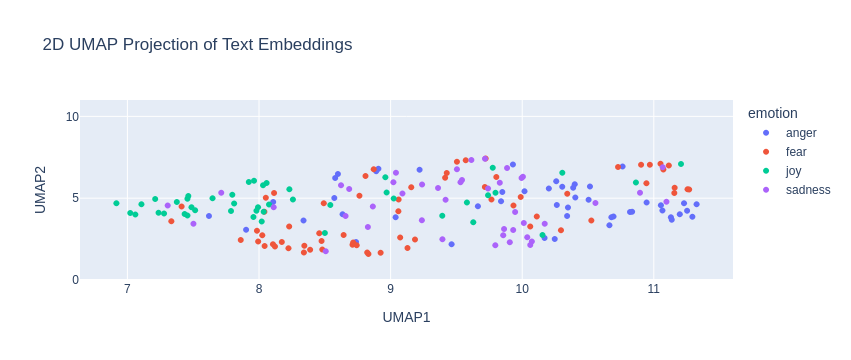

In [81]:
import pandas as pd
import numpy as np
import umap
import plotly.express as px

# Concatenate the training and test data
combined_df = pd.concat([train_df_new, test_df_new], ignore_index=True)

# Prepare the embeddings for UMAP
# Convert the list of embeddings into a 2D numpy array
X_embeddings = np.array(combined_df['embeddings_values'].tolist())

# Apply UMAP for dimensionality reduction
reducer = umap.UMAP(n_components=2, metric='cosine', random_state=28) 
embedding_2d = reducer.fit_transform(X_embeddings)

# Create a DataFrame for plotting
df_plot = pd.DataFrame(embedding_2d, columns=['UMAP1', 'UMAP2'])
df_plot['emotion'] = combined_df['emotion']
df_plot['intensity'] = combined_df['intensity']
df_plot['text'] = combined_df['text']


# Visualize the embeddings with Plotly
fig = px.scatter(
    df_plot,
    x='UMAP1',
    y='UMAP2',
    color='emotion',  # Color points by the 'emotion' column
    hover_data=['text', 'intensity'],  # Show text and intensity on hover
    title='2D UMAP Projection of Text Embeddings'
)

fig.update_yaxes(range=[0, 11])

fig.show()

We can see that even with Gemini's embeddings there doesn't seem to be a clear 2D separation of clusters with our data classes. It could be because emotions are often not discrete. Texts can contain mixed feelings (e.g., "bittersweet") or use similar language to express different emotions, causing their embeddings to be naturally close in semantic space. And also the process of projecting high-dimensional embeddings down to a 2D visualization inevitably loses some information, which can make distinct clusters appear to overlap.

---
##### <a id='toc1_5_8_1_1_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)

Apply UMAP to the same embeddings to reduce the dimensionality to 3D vectors and plot the 3D graph, discuss the differences and similarities with the 2D graph.

/home/momo/Documents/data-mining/DM2025Labs/DM2025-Lab2-Exercise/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



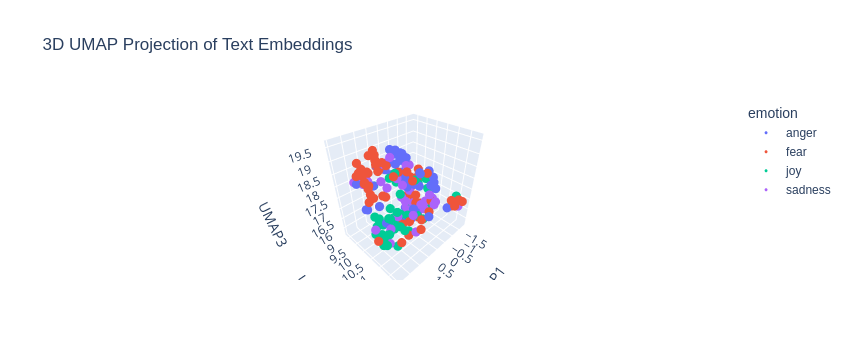

In [80]:
import pandas as pd
import numpy as np
import umap
import plotly.express as px

X_embeddings = np.array(combined_df['embeddings_values'].tolist())

# UMAP for 3d output
reducer_3d = umap.UMAP(
    n_components=3,
    metric='cosine',
    random_state=28
)

embedding_3d = reducer_3d.fit_transform(X_embeddings)

# dataframe for plotting
df_plot_3d = pd.DataFrame(embedding_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot_3d['emotion'] = combined_df['emotion']
df_plot_3d['intensity'] = combined_df['intensity']
df_plot_3d['text'] = combined_df['text']

# plot
fig = px.scatter_3d(
    df_plot_3d,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='emotion',
    hover_data=['text', 'intensity'],
    title='3D UMAP Projection of Text Embeddings'
)

fig.update_traces(marker=dict(size=3))

fig.show()



some of the general cluster shapes changed since the axis changed their ranges, it can also be noticed that emotions like anger, fear and sadness appear loosely grouped. these overlaps can be explained due to the semantic similarity across those emotions.

some clusters that looked merged in 2D spread out in the 3rd dimension, but if we take a look at some of the plane proyection of the points in the 3D plot, it does have some sort of resemblance with the 2D plot like in the example below: 

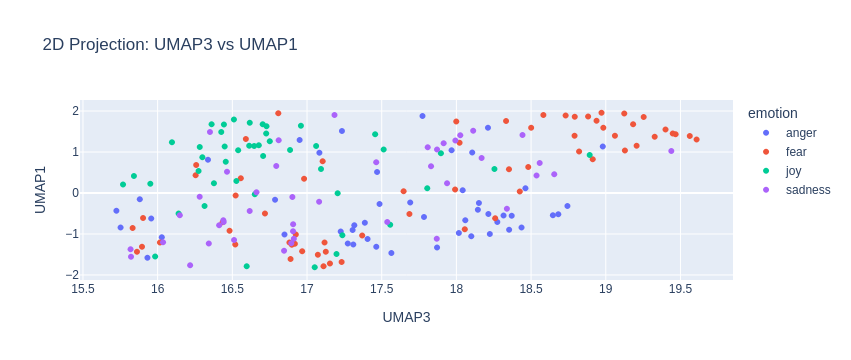

In [83]:
import plotly.express as px

fig = px.scatter(
    df_plot_3d,
    x='UMAP3',
    y='UMAP1',
    color='emotion',
    hover_data=['text', 'intensity'],
    title='2D Projection: UMAP3 vs UMAP1'
)

fig.show()


---
### <a id='toc1_5_9_'></a>[**2.5 Retrieval-Augmented Generation (RAG)**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

RAG (Retrieval-Augmented Generation) is a technique where a language model combines document retrieval with text generation. In RAG, a retrieval system first finds relevant documents or text chunks, and then the language model uses this retrieved information to generate a more informed and accurate response. This method enhances the model's ability to answer questions by grounding its responses in real, external data.

In the following code, we will load a webpage as a document, which allows us to retrieve text from a URL. After loading the content, we will split the document into smaller, manageable chunks, making it easier for our model to process. Then, we'll generate embeddings for these chunks with a specified LLM model (Gemini Embedding Model). These embeddings will be stored in a vector database, which enables us to perform similarity searches. By setting up this retrieval system, we can use a RAG chain to answer questions. The retriever finds relevant text chunks from the document based on a query, and the LLM generates a response by incorporating this retrieved information, making the answers more grounded and accurate.

In this example we use the library langchain, for documentation on more functions of the library you can check the following link: [LangChain Tutorials](https://python.langchain.com/docs/tutorials/)

In [84]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Function to load, split, and retrieve documents
def load_and_retrieve_docs(url):
    loader = WebBaseLoader(
        web_paths=(url,),
        bs_kwargs=dict() 
    ) 
    docs = loader.load() #We will load the URL that will serve as our data source
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150) #We will divide the URL in chunks of text for easier comparison in the vector space
    splits = text_splitter.split_documents(docs)
    #print(splits) #You can print this to see how the chunks in the url where split
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings) #Our vector space for comparison
    return vectorstore.as_retriever()


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) #Format the retrieved docs in an orderly manner for prompting

# Define the Gemini LLM function
def gemini_llm(question, context):
    system_prompt = "You are a RAG Agent that needs to provide a well structured answer based on the provided question and context."
    formatted_prompt = f"Question: {question}\n\nContext: {context}"
    response, logs = prompt_gemini(input_prompt = formatted_prompt, system_instruction = system_prompt, with_tokens_info = True)
    print(f"logs: \n{logs}")
    # print(f"Retrieved context: \n{context}\n\n") # You can print this to observe the retrieved context
    return response


# Define the RAG chain
def rag_chain(question, retriever):
    retrieved_docs = retriever.invoke(question)
    formatted_context = format_docs(retrieved_docs)
    return gemini_llm(question, formatted_context)


In [85]:
url="https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/"
# Create the retriever
retriever = load_and_retrieve_docs(url)

# Use the RAG chain
result = rag_chain(question="What are the Key Challenges in Realizing AGI’s Full Potential", retriever=retriever)
display(Markdown(result))

E0000 00:00:1763603443.820766 1016368 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1763603443.831738 1016368 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


logs: 
{'model': 'gemini-2.5-flash-lite', 'input_tokens': 726, 'output_tokens': 190}


The key challenges in realizing AGI's full potential stem from its fundamental requirements and the ethical considerations surrounding its development. These include:

*   **Learning from Diverse Data:** Unlike narrow AI, which is trained on structured data, AGI needs to learn from a wide variety of unstructured data sources.
*   **Computational Power:** The sheer amount of computational resources needed to process and learn from these vast and diverse datasets presents a significant hurdle.
*   **Ethical Concerns:** Developing AGI responsibly requires addressing critical ethical issues such as:
    *   **Bias and Fairness:** Ensuring algorithms are unbiased and treat everyone equally by training on diverse datasets and continuously monitoring performance.
    *   **Privacy:** Prioritizing user data protection through robust privacy measures and transparent data usage policies.
    *   **Accountability:** Establishing clear guidelines and legal frameworks to determine responsibility for decisions made by AGI systems and address any harm caused.


##### <a id='toc1_5_9_1_1_'></a>[**Actual answer in the URL:**](#toc0_)

![pic11.png](pics/pic11.png)

##### <a id='toc1_5_9_1_2_'></a>[**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc0_)

![pic12.png](pics/pic12.png)

source: https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/


---
##### <a id='toc1_5_9_1_3_'></a>[**>>> Bonus Exercise 5 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Your task is to test the RAG system with your own chosen URL and analyze its performance.

1. Find a URL of a webpage with interesting text content to test the RAG pipeline.
2. Make a question about the content in the webpage you chose.
3. Discuss how good the question was answered by the model, if the model missed important information related to your question.
4. Display a screenshot of the real answer in the webpage.

1. this is the URL that will be used to test the RAG pipeline: <code>https://www.activism.net/cypherpunk/manifesto.html</code>

2. here is a question about the content of the webpage:

In [86]:
url = "https://www.activism.net/cypherpunk/manifesto.html"

# create the retriever
retriever = load_and_retrieve_docs(url)

# question about the webpage
question = "Would you consider that a statement such as the cypherpunk manifesto would still be revelant in today's society despite the time that has passd since its making?"

# run the RAG chain
result = rag_chain(question=question, retriever=retriever)

# display result
display(Markdown(result))

E0000 00:00:1763604439.982108 1016368 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1763604439.983868 1016368 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


logs: 
{'model': 'gemini-2.5-flash-lite', 'input_tokens': 759, 'output_tokens': 336}


Yes, the Cypherpunk Manifesto remains highly relevant in today's society. Here's why:

*   **Core Principles of Privacy:** The manifesto's central argument that "Privacy is necessary for an open society in the electronic age" is more pertinent than ever. In an era of pervasive data collection, surveillance, and digital footprints, the need to selectively reveal oneself and maintain control over personal information is a critical concern.

*   **Critique of Cryptography Regulations:** The manifesto's stance against regulations on cryptography, viewing encryption as a private act, resonates with ongoing debates about government access to encrypted data and the balance between security and privacy. The prediction that cryptography would spread globally has proven accurate.

*   **Empowerment Through Technology:** The Cypherpunks' dedication to building anonymous systems and defending privacy with cryptography, digital signatures, and electronic money aligns with the development of technologies like secure messaging apps, cryptocurrencies, and privacy-enhancing tools that are widely used today.

*   **Skepticism of Large Organizations:** The manifesto's distrust of governments and corporations regarding privacy is a sentiment shared by many today. The document correctly anticipates that these entities may not prioritize individual privacy and that individuals must actively defend it.

*   **The Nature of Information:** The description of information as something that "longs to be free" and expands to fill available space accurately reflects the current digital landscape, where data is constantly generated, shared, and stored, making privacy a continuous challenge.

In essence, the Cypherpunk Manifesto articulated fundamental principles and concerns about privacy in the digital age that continue to be highly relevant and debated today.

----

3. The question was answered acurrately enough, the explicit answer was not provided in the text but the model was good enough to infer the response from it.it also did a good enough job at providing some examples from the text that would support its conclusion and answer to the question asked.

4. here are a few screenshots of the information contained in the webpage that can answer the question and where the model extracted it from:
 

![s1 screenshot](./data/documents/s1.png)
![s2 screenshot](./data/documents/s2.png)
![s3 screenshot](./data/documents/s3.png)

---
### <a id='toc1_5_10_'></a>[**2.6 Few-Shot Prompting Classification:**](#toc0_)

Few-shot prompting is a technique where a Large Language Model (LLM) is given a small number of labeled examples within a prompt to guide its classification. This allows the model to perform a new task with minimal data, avoiding the need for extensive fine-tuning.

In this lab, we will use the Gemini API to perform zero-shot, 1-shot, and 5-shot emotion classification:

*   **Zero-shot:** The model classifies text without any prior examples.
*   **1-shot:** The model is given one example for each emotion before classifying.
*   **5-shot:** The model is given five examples per emotion for better context.

To make our implementation robust and efficient, we are incorporating two key features:

1.  **Structured Output:** We provide the Gemini model with a specific output schema (`Emotions` class). This instructs the model to return *only* a valid emotion label (e.g., `joy`), which makes the output predictable and reliable, minimizing errors.
2.  **API Rate Handling:** The code includes a function to manage the requests-per-minute limit of the Gemini API.

We will test the model's performance on a small sample of 20 texts per emotion to ensure the process runs quickly. If the model provides an invalid response, the code will automatically retry the request until a valid classification is received.

**Prompt Structure:**
`System Instruction -> Task Description -> Examples (if not zero-shot) -> Text to Classify`


<span style="color:green">For the exercises in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

In [87]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import enum
import os
from tqdm import tqdm
import json
import time
# Define the emotion labels
emotions = ['anger', 'fear', 'joy', 'sadness']
# Define the model to use for few-shot prompting

# Schema for the output, the type enum can be used to make a pool of options if what we want is to classify our text selecting only one of them
class Emotions(enum.StrEnum):
    ANGER = 'anger'
    FEAR = 'fear'
    JOY = 'joy'
    SADNESS = 'sadness'


# Function to handle the rate limits of gemini models
def handle_rate_limit(request_count, first_request_time, max_calls_per_min):
    current_time = time.time()

    # Initialize timer on the first request of a new window
    if request_count == 0:
        first_request_time = current_time

    request_count += 1

    # If the rate limit is reached
    if request_count > max_calls_per_min:
        elapsed_time = current_time - first_request_time
        if elapsed_time < 60:
            wait_time = 60 - elapsed_time
            print(f"Rate limit of {max_calls_per_min} requests per minute reached. Waiting for {wait_time:.2f} seconds.")
            time.sleep(wait_time)

        # Reset for the new window
        request_count = 1
        first_request_time = time.time()
    
    return request_count, first_request_time, max_calls_per_min

# Function to sample examples per emotion category
def sample_few_shots(df, emotions, num_samples=5):
    few_shot_examples = {}
    for emotion in emotions:
        few_shot_examples[emotion] = df[df['emotion'] == emotion].sample(n=num_samples, random_state=42)
    return few_shot_examples

# Function to build the prompt based on the number of examples (few-shot, 1-shot, zero-shot)
def build_prompt(examples, emotions, num_shots=5):
    classification_instructions = """
You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    """
    
    prompt = classification_instructions + "\n\n"
    
    if num_shots > 0:
        prompt += f"Examples: \n"
        for emotion in emotions:
            for _, row in examples[emotion].iterrows():
                prompt += f"Text: {row['text']}\nClass: {emotion}\n\n" #Show the examples in the same format it will be shown for the classification text
                if num_shots == 1:  # If 1-shot, break after the first example for each emotion
                    break
    return prompt

# Function to classify using the LLM with retry for incorrect responses
def classify_with_llm(test_text, prompt_base, system_prompt, classes, schema):
    response = None
    while not response or response not in classes:
        full_prompt = f"{prompt_base}\nClassification:\nText: {test_text}\nClass: " #The classification text will leave the emotion label to be filled in by the LLM
        try:
            result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt)
            # print(f"result: {result} \n")
            # print(f"type: {type(result)}")
            if not result:
                # In case of giving empty responses with temperature 0.0, we set a higher temperature to seek for different responses
                result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt, temperature=1.0)

            try:
                # If the result is in the correct format it can be parsed using json
                response = json.load(result)
            except:
                # In case it's not in a json friendly format
                # Deleting characters " and ' in case they appear in our response with the class of the text 
                response = result.replace('"', '')    
                response = response.replace("'", "")  

                
        # except exceptions.ResourceExhausted as e:
        except Exception as e:
            print(f"Waiting to retry... Error: {e}")
            time.sleep(15)
            print(f"test_text: {test_text}")
            return classify_with_llm(test_text, prompt_base, system_prompt, classes, schema) # Retry the request


        if response not in classes:  # Retry if not a valid response
            print(f"Invalid response: {response}. Asking for reclassification.")
    return response

# Main function to run the experiment with the option for zero-shot, 1-shot, or 5-shot prompting
def run_experiment(df_train, df_test, num_test_samples=5, num_shots=5):
    # Sample examples for few-shot prompting based on num_shots
    if num_shots > 0:
        few_shot_examples = sample_few_shots(df_train, emotions, num_samples=num_shots) 
        prompt_base = build_prompt(few_shot_examples, emotions, num_shots=num_shots)
    else:
        prompt_base = build_prompt(None, emotions, num_shots=0)  # Zero-shot has no examples

    # System prompt for our classification model:
    system_prompt = "You are an emotion classification model for text data. Do not give empty responses, classify according to the list of possible classes."

    # Prepare to classify the test set
    results_data = []

    print(prompt_base)
    # Sample 20 examples per emotion for the test set to classify
    test_samples = sample_few_shots(df_test, emotions, num_samples=num_test_samples)

    # Variables to handle rate limit of gemini
    request_count = 0
    max_calls_per_min = 15 # Gemini 2.5 Flash Lite has this maximum set in the documentation
    first_request_time = None

    # Classify 20 test examples (5 from each category) and save predictions
    for emotion in emotions:
        for _, test_row in tqdm(test_samples[emotion].iterrows(), desc=f"Processing samples for emotion: {emotion}...", total=num_test_samples):
            test_text = test_row['text']
            request_count, first_request_time, max_calls_per_min = handle_rate_limit(request_count, first_request_time, max_calls_per_min)  # Check and handle rate limit before each API call
            predicted_emotion = classify_with_llm(test_text = test_text, prompt_base = prompt_base, system_prompt = system_prompt, classes = emotions, schema = Emotions)
            # Append the results data:
            results_data.append({
                    'text': test_text,
                    'true_emotion': emotion,
                    'predicted_emotion': predicted_emotion
                })

    # Create dataframe to save the results data
    results_df = pd.DataFrame(results_data)
    
    # Extract just the true and predicted labels for metrics calculations
    true_labels = results_df['true_emotion']
    predictions = results_df['predicted_emotion']

    output_dir = "./results/llm_classification_results"
    os.makedirs(output_dir, exist_ok=True)
    # Save the results
    filename = f"{output_dir}/results_samples_{num_test_samples}_shots_{num_shots}.csv"
    
    # Save the DataFrame to CSV
    results_df.to_csv(filename, index=False)
    print(f"\nResults saved to {filename}")

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    
    # Classification report
    print(classification_report(y_true=true_labels, y_pred=predictions))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true=true_labels, y_pred=predictions) 
    my_tags = ['anger', 'fear', 'joy', 'sadness']
    plot_confusion_matrix(cm, classes=my_tags, title=f'Confusion matrix for classification with \n{num_shots}-shot prompting')

**Important: The next part should take around 16 minutes to finish running due to API Rate Limits**

**Note:** You might see an `429 RESOURCE_EXHAUSTED` error when running the following code all at once, this is because the `current API Rate Limit handling cannot reliably find out how many requests we have left per minute` from cell to cell, there is no Gemini feature created for it to get the information from their servers. So, `if you don't want to see the error you can just wait 1 minute` after one cell finished processing. But `even if there is an error showing it is fine`, internally in the code `there is a retry that happens every 15 seconds` until we finish processing our sampled data. `The lab is designed to never reach the total rate limit per day quota.`


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    




Processing samples for emotion: anger...:  75%|████████████████████████████████████            | 15/20 [00:28<00:08,  1.62s/it]

Rate limit of 15 requests per minute reached. Waiting for 31.89 seconds.


Processing samples for emotion: fear...:  50%|████████████████████████▌                        | 10/20 [00:13<00:14,  1.48s/it]

Rate limit of 15 requests per minute reached. Waiting for 36.18 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 34.94 seconds.


Processing samples for emotion: sadness...:  75%|██████████████████████████████████▌           | 15/20 [01:03<00:09,  1.92s/it]

Rate limit of 15 requests per minute reached. Waiting for 31.76 seconds.


Processing samples for emotion: sadness...: 100%|██████████████████████████████████████████████| 20/20 [01:43<00:00,  5.18s/it]


Results saved to ./results/llm_classification_results/results_samples_20_shots_0.csv
Accuracy: 50.00%
              precision    recall  f1-score   support

       anger       0.50      0.65      0.57        20
        fear       0.67      0.20      0.31        20
         joy       0.44      0.80      0.57        20
     sadness       0.58      0.35      0.44        20

    accuracy                           0.50        80
   macro avg       0.55      0.50      0.47        80
weighted avg       0.55      0.50      0.47        80



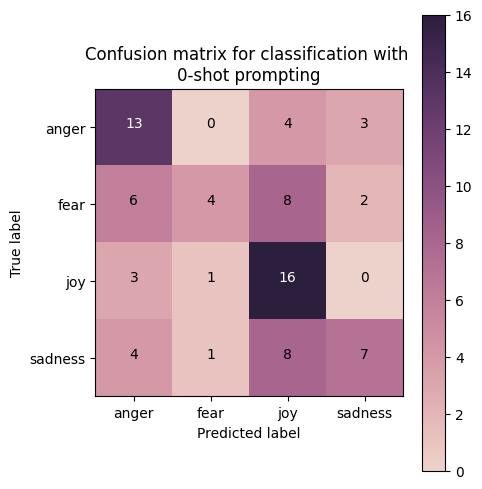

In [89]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with zero-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=0)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: @KimLy resent
Class: anger

Text: Being stuck in the roof of your house provides amazing view but sheer terror of falling down, kinda like life
Class: fear

Text: sparkling or still? #terribledebatequestions
Class: joy

Text: #vinb I'm alot more interested in hearing bout differences between parties political ideologies. Parties murky origins r irrefutable #vinb
Class: sadness




Processing samples for emotion: anger...:  75%|████████████████████████████████████            | 15/20 [00:23<00:07,  1.58s/it]

Rate limit of 15 requests per minute reached. Waiting for 36.49 seconds.


Processing samples for emotion: fear...:  50%|████████████████████████▌                        | 10/20 [00:14<00:12,  1.30s/it]

Rate limit of 15 requests per minute reached. Waiting for 35.35 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 35.24 seconds.


Processing samples for emotion: sadness...:  75%|██████████████████████████████████▌           | 15/20 [01:00<00:07,  1.58s/it]

Rate limit of 15 requests per minute reached. Waiting for 34.82 seconds.


Processing samples for emotion: sadness...: 100%|██████████████████████████████████████████████| 20/20 [01:43<00:00,  5.17s/it]


Results saved to ./results/llm_classification_results/results_samples_20_shots_1.csv
Accuracy: 55.00%
              precision    recall  f1-score   support

       anger       0.63      0.60      0.62        20
        fear       0.71      0.25      0.37        20
         joy       0.48      0.80      0.60        20
     sadness       0.52      0.55      0.54        20

    accuracy                           0.55        80
   macro avg       0.59      0.55      0.53        80
weighted avg       0.59      0.55      0.53        80



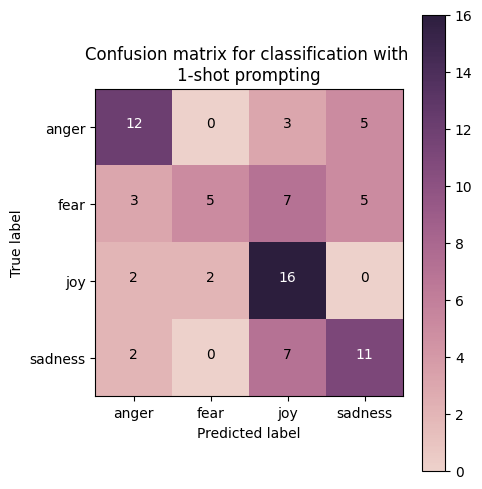

In [90]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 1-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=1)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: @KimLy resent
Class: anger

Text: This all resent #India #Pakistan problem is save #NawazSharif\n@ImranKhanPTI\n@PTIofficial
Class: anger

Text: @BigBrother__USA she is just jealous and a cry baby! #bitter #gladsheisgone #crybaby
Class: anger

Text: @ggreenwald Smh, remove ideologically bankrupt and opportunistic establishment now. They're burning all bridges and social contracts. 
Class: anger

Text: @JasonMillerinDC @realDonaldTrump Prudence suggests that a 8+% bump over 2-3 weeks should be viewed with SKEPTICISM. Media/HRC axis 
Class: anger

Text: Being stuck in the roof of your house provides amazing view but sheer terror of falling down, kinda like life
Class: fear

Text: @LBC - I can't read this article but headline indicates a horror story. Lock sick chavs up and throw away the key.

Processing samples for emotion: anger...:  75%|████████████████████████████████████            | 15/20 [00:28<00:09,  1.86s/it]

Rate limit of 15 requests per minute reached. Waiting for 31.76 seconds.


Processing samples for emotion: fear...:  50%|████████████████████████▌                        | 10/20 [00:16<00:17,  1.75s/it]

Rate limit of 15 requests per minute reached. Waiting for 34.03 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 33.70 seconds.


Processing samples for emotion: sadness...:  75%|██████████████████████████████████▌           | 15/20 [00:58<00:08,  1.63s/it]

Rate limit of 15 requests per minute reached. Waiting for 35.64 seconds.


Processing samples for emotion: sadness...: 100%|██████████████████████████████████████████████| 20/20 [01:44<00:00,  5.23s/it]


Results saved to ./results/llm_classification_results/results_samples_20_shots_5.csv
Accuracy: 53.75%
              precision    recall  f1-score   support

       anger       0.59      0.50      0.54        20
        fear       0.64      0.35      0.45        20
         joy       0.52      0.80      0.63        20
     sadness       0.48      0.50      0.49        20

    accuracy                           0.54        80
   macro avg       0.55      0.54      0.53        80
weighted avg       0.55      0.54      0.53        80



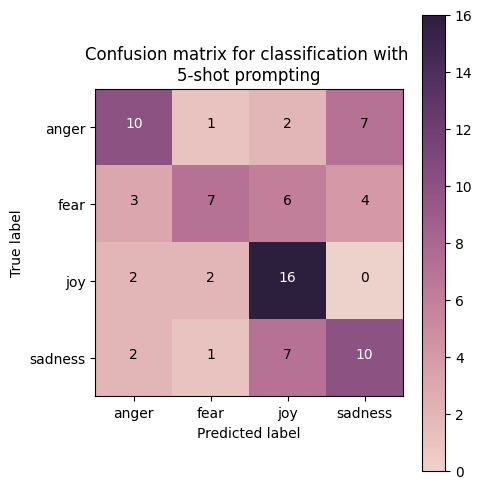

In [91]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 5-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=5)

---
##### <a id='toc1_5_10_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Compare and discuss the overall results of the zero-shot, 1-shot and 5-shot classification.

The zero-shot had an accuracy of 50% with 'fear' being the classification with lowest score (re call was 20%). This can be explained due to the fact that fear may be easily confused with anger or sadness.

The 1-shot had 55% accuracy and had the best overall result. some of the factors that may lead to this classification model to perfom so well even compared with the 5-shot are that the model avoids overfitting. the lowest score was still 'fear' but the recall improved by 5%. 

The 5-shot model performed better than the zero-shot model but slighly worse than the 1-shot. it most likely was biased toward majority emotion patterns in the examples since there were more of them and more examples lead to the model getting confused rather than improving the results. 

---
##### <a id='toc1_5_10_1_2_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

**Case Study:** Check the results' files inside the `results/llm_classification_results` directory and find cases where the **text classification improves with more examples** (pred emotion is right with examples), **cases where it does not improve** (pred emotion always wrong) and **cases where the classification got worse with more examples** (pred emotion goes from right to wrong with examples). For this you need to load the results with pandas and handle the data using its dataframe functions. Discuss about the findings.

In [111]:
import pandas as pd

base_dir = "./results/llm_classification_results"

df0 = pd.read_csv(f"{base_dir}/results_samples_20_shots_0.csv")
df1 = pd.read_csv(f"{base_dir}/results_samples_20_shots_1.csv")
df5 = pd.read_csv(f"{base_dir}/results_samples_20_shots_5.csv")

# check columns
display(df0.head())
display(df1.head())
display(df5.head())

,text,true_emotion,predicted_emotion
0,@LaureEve I am sitting here wrapped in a fluff...,anger,joy
1,(Sam) Brown's Law: Never offend people with st...,anger,anger
2,@ZubairSabirPTI pls dont insult the word 'Molna',anger,anger
3,Just joined #pottermore and was sorted into HU...,anger,anger
4,Everybody talking about 'the first day of fall...,anger,joy


,text,true_emotion,predicted_emotion
0,@LaureEve I am sitting here wrapped in a fluff...,anger,joy
1,(Sam) Brown's Law: Never offend people with st...,anger,anger
2,@ZubairSabirPTI pls dont insult the word 'Molna',anger,anger
3,Just joined #pottermore and was sorted into HU...,anger,anger
4,Everybody talking about 'the first day of fall...,anger,joy


,text,true_emotion,predicted_emotion
0,@LaureEve I am sitting here wrapped in a fluff...,anger,joy
1,(Sam) Brown's Law: Never offend people with st...,anger,sadness
2,@ZubairSabirPTI pls dont insult the word 'Molna',anger,anger
3,Just joined #pottermore and was sorted into HU...,anger,anger
4,Everybody talking about 'the first day of fall...,anger,joy


the columns of each table for the predicted emotion will be renamed based on the original document to help with the comparison of them

In [94]:
df0 = df0.rename(columns={"predicted_emotion": "pred_0"})
df1 = df1.rename(columns={"predicted_emotion": "pred_1"})
df5 = df5.rename(columns={"predicted_emotion": "pred_5"})

we can join them in a sinlge data frame for easier processing:

In [95]:
merged = (
    df0[["text", "true_emotion", "pred_0"]]
    .merge(df1[["text", "true_emotion", "pred_1"]], on=["text", "true_emotion"])
    .merge(df5[["text", "true_emotion", "pred_5"]], on=["text", "true_emotion"])
)

print(merged.shape)
merged.head()

(80, 5)


,text,true_emotion,pred_0,pred_1,pred_5
0,@LaureEve I am sitting here wrapped in a fluff...,anger,joy,joy,joy
1,(Sam) Brown's Law: Never offend people with st...,anger,anger,anger,sadness
2,@ZubairSabirPTI pls dont insult the word 'Molna',anger,anger,anger,anger
3,Just joined #pottermore and was sorted into HU...,anger,anger,anger,anger
4,Everybody talking about 'the first day of fall...,anger,joy,joy,joy


now we can add additional columns that will contain the result of each prediction based on the true emotion:

In [99]:
correct_0 = merged["pred_0"] == merged["true_emotion"]
correct_1 = merged["pred_1"] == merged["true_emotion"]
correct_5 = merged["pred_5"] == merged["true_emotion"]

merged = merged.assign(
    correct_0 = correct_0,
    correct_1 = correct_1,
    correct_5 = correct_5,
)
merged.head()

,text,true_emotion,pred_0,pred_1,pred_5,correct_0,correct_1,correct_5
0,@LaureEve I am sitting here wrapped in a fluff...,anger,joy,joy,joy,False,False,False
1,(Sam) Brown's Law: Never offend people with st...,anger,anger,anger,sadness,True,True,False
2,@ZubairSabirPTI pls dont insult the word 'Molna',anger,anger,anger,anger,True,True,True
3,Just joined #pottermore and was sorted into HU...,anger,anger,anger,anger,True,True,True
4,Everybody talking about 'the first day of fall...,anger,joy,joy,joy,False,False,False


finally we can check each case individually.

for the results that improve with more examples:

In [107]:
improved = merged[
    (~merged["correct_0"]) & (merged["correct_1"] | merged["correct_5"])
]
print("improved with examples:", len(improved))
improved.head()

improved with examples: 8


,text,true_emotion,pred_0,pred_1,pred_5,correct_0,correct_1,correct_5
12,Eat my ass' is no longer an insult,anger,joy,anger,anger,False,True,True
20,About 7 weeks till I can pick up my camera aga...,fear,joy,joy,fear,False,False,True
28,Trying to book holiday flights on @britishairw...,fear,anger,fear,fear,False,True,True
34,"But I was so intrigued by your style, boy.Alwa...",fear,joy,joy,fear,False,False,True
65,I can't WAIT to go to work tomorrow with a hig...,sadness,anger,sadness,sadness,False,True,True


cases that got worse with more examples:

In [108]:
got_worse = merged[
    (merged["correct_0"]) & (~merged["correct_1"]) & (~merged["correct_5"])
]
print("got worse with examples:", len(got_worse))
got_worse.head()

got worse with examples: 2


,text,true_emotion,pred_0,pred_1,pred_5,correct_0,correct_1,correct_5
11,@RevTrevK @Wolfman93011 @Daraidernation @EROCK...,anger,anger,sadness,sadness,True,False,False
13,Sting is just too damn earnest for early morni...,anger,anger,sadness,sadness,True,False,False


and cases that were never correct:

In [110]:
never_correct = merged[
    (~merged["correct_0"]) & (~merged["correct_1"]) & (~merged["correct_5"])
]
print("Always wrong:", len(never_correct))
never_correct.head(11)

Always wrong: 32


,text,true_emotion,pred_0,pred_1,pred_5,correct_0,correct_1,correct_5
0,@LaureEve I am sitting here wrapped in a fluff...,anger,joy,joy,joy,False,False,False
4,Everybody talking about 'the first day of fall...,anger,joy,joy,joy,False,False,False
7,Having a baby born too soon is #lifechanging 6...,anger,sadness,sadness,sadness,False,False,False
8,Might just leave and aggravate bae,anger,sadness,sadness,sadness,False,False,False
10,@UKBlogAwards @ModishMale I would always be ho...,anger,joy,joy,sadness,False,False,False
18,Sorry guys I have absolutely no idea what time...,anger,sadness,sadness,sadness,False,False,False
21,Rooney shocking attempted cross,fear,anger,sadness,sadness,False,False,False
23,I know this is going to be one of those nights...,fear,sadness,sadness,sadness,False,False,False
24,"it's horrible cos no one can relate, everyone...",fear,sadness,sadness,sadness,False,False,False
26,So about 18mths ago i signed up to @Lumo_Energ...,fear,anger,sadness,sadness,False,False,False


the best way to discuss the results is to take a look into some of the 'text' columns for each case

In [120]:
pd.set_option("display.max_colwidth", None)

def show_examples(df, n=5, title=""):
    print(f"\n{title} (lentgth={len(df)}):")
    display(df[["text", "true_emotion", "pred_0", "pred_1", "pred_5"]].head(n))

show_examples(improved, title="improved with examples")
show_examples(got_worse, title="got worse with examples")
show_examples(never_correct, title="always wrong")


improved with examples (lentgth=8):


,text,true_emotion,pred_0,pred_1,pred_5
12,Eat my ass' is no longer an insult,anger,joy,anger,anger
20,About 7 weeks till I can pick up my camera again. Though I think there is a group cemetery shoot in october I can make! #photography #horror,fear,joy,joy,fear
28,Trying to book holiday flights on @britishairways website is becoming a #nightmare,fear,anger,fear,fear
34,"But I was so intrigued by your style, boy.Always been a sucker for a wild boy #alarm -@AnneMarieIAm",fear,joy,joy,fear
65,I can't WAIT to go to work tomorrow with a high as fuck fever. [sarcasm]\nHopefully I'll feel better tomorrow.\nBut I doubt it. #pessimism,sadness,anger,sadness,sadness



got worse with examples (lentgth=2):


,text,true_emotion,pred_0,pred_1,pred_5
11,@RevTrevK @Wolfman93011 @Daraidernation @EROCKhd Take 2k out of it the numbers on madden are low and have dropped and people are unhappy,anger,anger,sadness,sadness
13,Sting is just too damn earnest for early morning listening.,anger,anger,sadness,sadness



always wrong (lentgth=32):


,text,true_emotion,pred_0,pred_1,pred_5
0,"@LaureEve I am sitting here wrapped in a fluffy blanket, with incense burning, listening to Bon Iver and drinking mulled wine. I'm there.",anger,joy,joy,joy
4,Everybody talking about 'the first day of fall' but summer '16 is never gonna die #revenge @Drake,anger,joy,joy,joy
7,Having a baby born too soon is #lifechanging 6 years on and it feels like only yesterday #sad #happy #angry #emotionalrollercoaster,anger,sadness,sadness,sadness
8,Might just leave and aggravate bae,anger,sadness,sadness,sadness
10,@UKBlogAwards @ModishMale I would always be honest but it's great to feedback opinion to the brand - don't want to offend them #BlogHour,anger,joy,joy,sadness


**Improved with examples**

Here are some examples of the type of text that was able to improve with additional 'shots':

* Eat my ass' is no longer an insult	

* About 7 weeks till I can pick up my camera again. Though I think there is a group cemetery shoot in october I can make! #photography #horror	

* Trying to book holiday flights on @britishairways website is becoming a #nightmare

* But I was so intrigued by your style, boy.Always been a sucker for a wild boy #alarm -@AnneMarieIAm

* I can't WAIT to go to work tomorrow with a high as fuck fever. [sarcasm]\nHopefully I'll feel better tomorrow.\nBut I doubt it. #pessimism

In these cases, the n-shot examples clarify some of the  ambiguities that the text has, like hashtags, emojis, and sarcasm. the model adjusts better with the additional examples and is able to improve the final decision 

**Got worse with examples**

Here are some examples of the type of text that got worse with additional 'shots':

* @RevTrevK @Wolfman93011 @Daraidernation @EROCKhd Take 2k out of it the numbers on madden are low and have dropped and people are unhappy	anger	anger	sadness	sadness

* Sting is just too damn earnest for early morning listening.

This group has a total of 2 rows that fell into the category, this shows that in some very particular cases more examples can introduce bias and noise. the zero shot was able to get both of these correct, so it implies that some sort of pattern was picked with by the model due to the additional examples that lead it towards a different prediction.

**Always wrong**

Here are some examples of the type of text that was able to improve with additional 'shots':

* @LaureEve I am sitting here wrapped in a fluffy blanket, with incense burning, listening to Bon Iver and drinking mulled wine. I'm there.
  
* Everybody talking about 'the first day of fall' but summer '16 is never gonna die #revenge @Drake

* Having a baby born too soon is #lifechanging 6 years on and it feels like only yesterday #sad #happy #angry #emotionalrollercoaster

* Might just leave and aggravate bae

* @UKBlogAwards @ModishMale I would always be honest but it's great to feedback opinion to the brand - don't want to offend them #BlogHour

These were the hardest cases for the model and also the ones that had the largest amount (32). Some of the cases were responses to other users and also had some context around them that would have helped the model predict the outcome more accurately, however, without the context, it's would be hard for most humans to accurately predict the true emotion of the text as well.

These are good illustrations of the intrinsic ambiguity of emotion classification.

---
### <a id='toc1_5_11_'></a>[**2.7 Extra LLM Related Materials:**](#toc0_)
So this will be it for the lab, but here are some extra materials if you would like to explore:

- **How to use OpenAI ChatGPT model's API (Not Free API):** [Basics Video](https://www.youtube.com/watch?v=e9P7FLi5Zy8), [Basics GitHub](https://github.com/gkamradt/langchain-tutorials/blob/main/chatapi/ChatAPI%20%2B%20LangChain%20Basics.ipynb), [RAG's Basics Video](https://www.youtube.com/watch?v=9AXP7tCI9PI&t=300s), [RAG's Basics GitHub](https://github.com/techleadhd/chatgpt-retrieval)

- **Advanced topic - QLoRA (Quantized Low-Rank Adapter):** QLoRA is a method used to make fine-tuning large language models more efficient. It works by adding a small, trainable part (LoRA) to a pre-trained model, while keeping the rest of the model frozen. At the same time, it reduces the size of the model’s data using a process called quantization, which makes the model require less memory. This allows you to fine-tune large models without needing as much computational power, making it easier to adapt models for specific tasks. Materials: [Paper GitHub](https://github.com/artidoro/qlora?tab=readme-ov-file), [Llama 3 Application Video](https://www.youtube.com/watch?v=YJNbgusTSF0&t=512s),[Llama 3 Application GitHub](https://github.com/adidror005/youtube-videos/blob/main/LLAMA_3_Fine_Tuning_for_Sequence_Classification_Actual_Video.ipynb)

- **How to Fine-tune and run local LLMs with the `unsloth` library:** [unsloth tutorials](https://docs.unsloth.ai/models/tutorials-how-to-fine-tune-and-run-llms)

- **Google's Agent Development Kit Documentation:** [ADK](https://google.github.io/adk-docs/)

- **Build AI agents with LangGraph:** [LangGraph Documentation](https://langchain-ai.github.io/langgraph/concepts/why-langgraph/)

---